# Post mofa-flex analysis

### Contents:

1. [Load models (Normal, SnS, and GP).](#load-models)

2. [MOFA-Flex model result overview.](#mofa-flex-results-overview)
<br>
2.1 [Factor correlation and variance explained.](#1-variance-explained)
<br>
2.2 [Average R2.](#2-average-r2)
<br>
2.3 [Weights distribution.](#3weights-dist)
<br>
2.4 [Heatmap (view x LR).](#4-heatmap-view-x-lr)

3. [DR and clustering.](#dr-using-factors-values)

4. [Regression Model.](#regression-model)
<br>
4.1 [Evaluate model.](#evaluate-the-model)
<br>
4.2 [AUC.](#auc)

5. [Map clusters to spatial.](#map-clusters-to-spatial)

In [1]:
import os.path
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from umap import UMAP
from sklearn.manifold import TSNE

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



# Run MOFA

## Read mdata

In [2]:
mdata_path = Path("/g/stegle/aalsayah/repos/data/merfish")

In [ ]:
mdata = md.read(mdata_path / "lrdata_animal2_C57BL6J-2.034.h5mu")

In [ ]:
mdata

In [5]:
del mdata.mod["glycinergic_neuron"]
del mdata.mod["monocyte"]
del mdata.mod["histaminergic_neuron"]
del mdata.mod["dopaminergic_neuron"]
del mdata.mod["dendritic_cell"]
del mdata.mod["cholinergic_neuron"]
del mdata.mod["macrophage"]
del mdata.mod["lymphocyte"]
del mdata.mod["smooth_muscle_cell"]
del mdata.mod["pericyte"]

In [11]:
import mudata as mu
mdata_new = mu.MuData({mod: ad for mod, ad in mdata.mod.items()})

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


In [ ]:
mdata_new

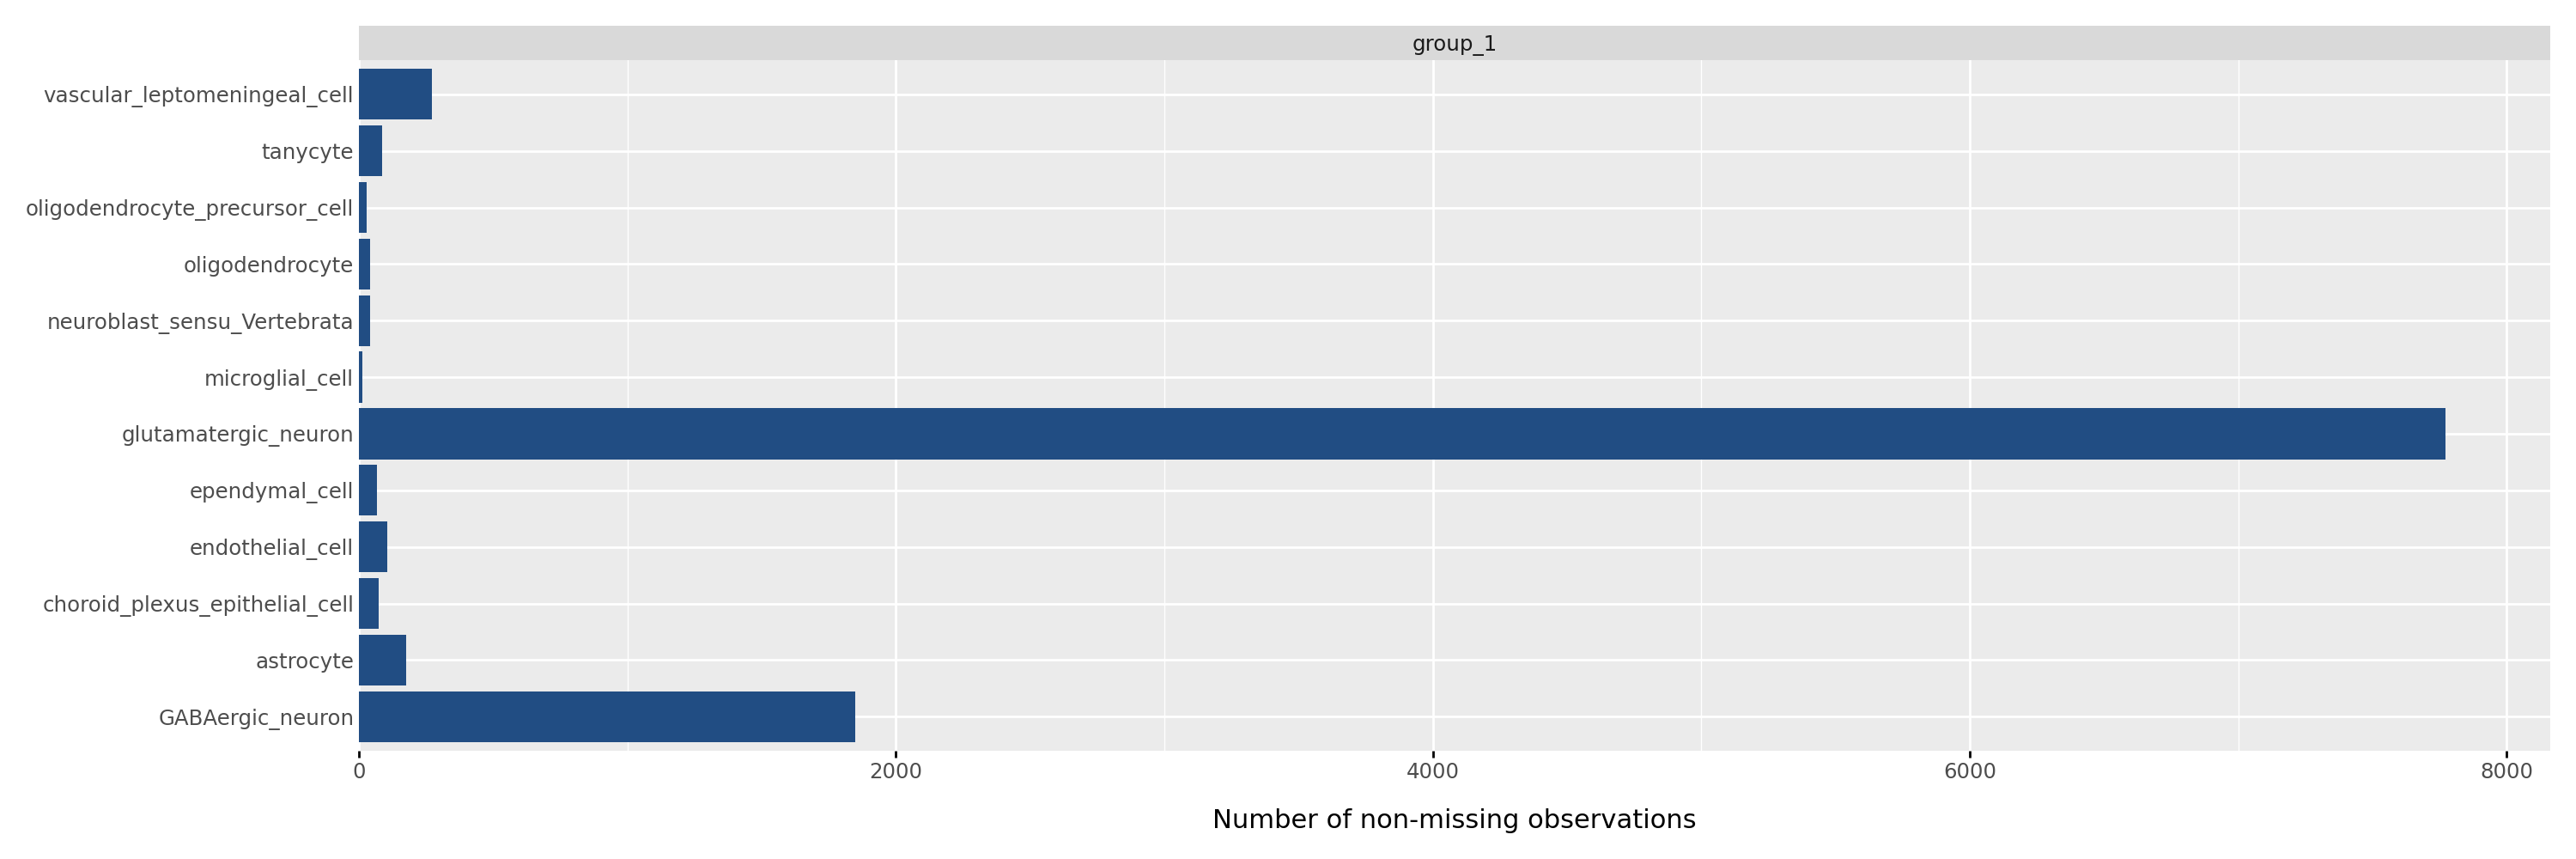

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default any

  0%|                                                                                                      | 0…

INFO	Training converged after 980 epochs.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
INFO	Saving results to /g/stegle/aalsayah/repos/data/merfish/mofa_model_temp.hdf5...
WARNING	/g/stegle/aalsayah/repos/data/merfish/mofa_model_temp.hdf5 already exists

In [120]:
model = mfl.MOFAFLEX(
    mdata_new,
    mfl.ModelOptions(
        n_factors=10,
        factor_prior="Normal",
        likelihoods="Normal",
        weight_prior="SnS",
    ),
    mfl.TrainingOptions(
        batch_size=2000,
        n_particles=10,
        lr=0.005,
        max_epochs=1000,
        save_path=str("/g/stegle/aalsayah/repos/data/merfish/mofa_model_temp.hdf5"),
        early_stopper_patience=50,
    ),
)

# Load models

### Normal

In [ ]:
models_path = Path("/g/stegle/aalsayah/repos/data/merfish")

In [ ]:
model= mfl.MOFAFLEX.load(models_path / 'mofa_model_temp.hdf5')

### SnS

In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "sns_models/crc_110/Normal.SnS/crc_110.Normal.SnS.hdf5")

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


### GP

In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "GP_models/crc_232_no_mye_IgM/GP.Normal/crc_232_no_mye_IgM.GP.Normal.hdf5")

# MOFA-Flex results overview

## 1. Variance Explained

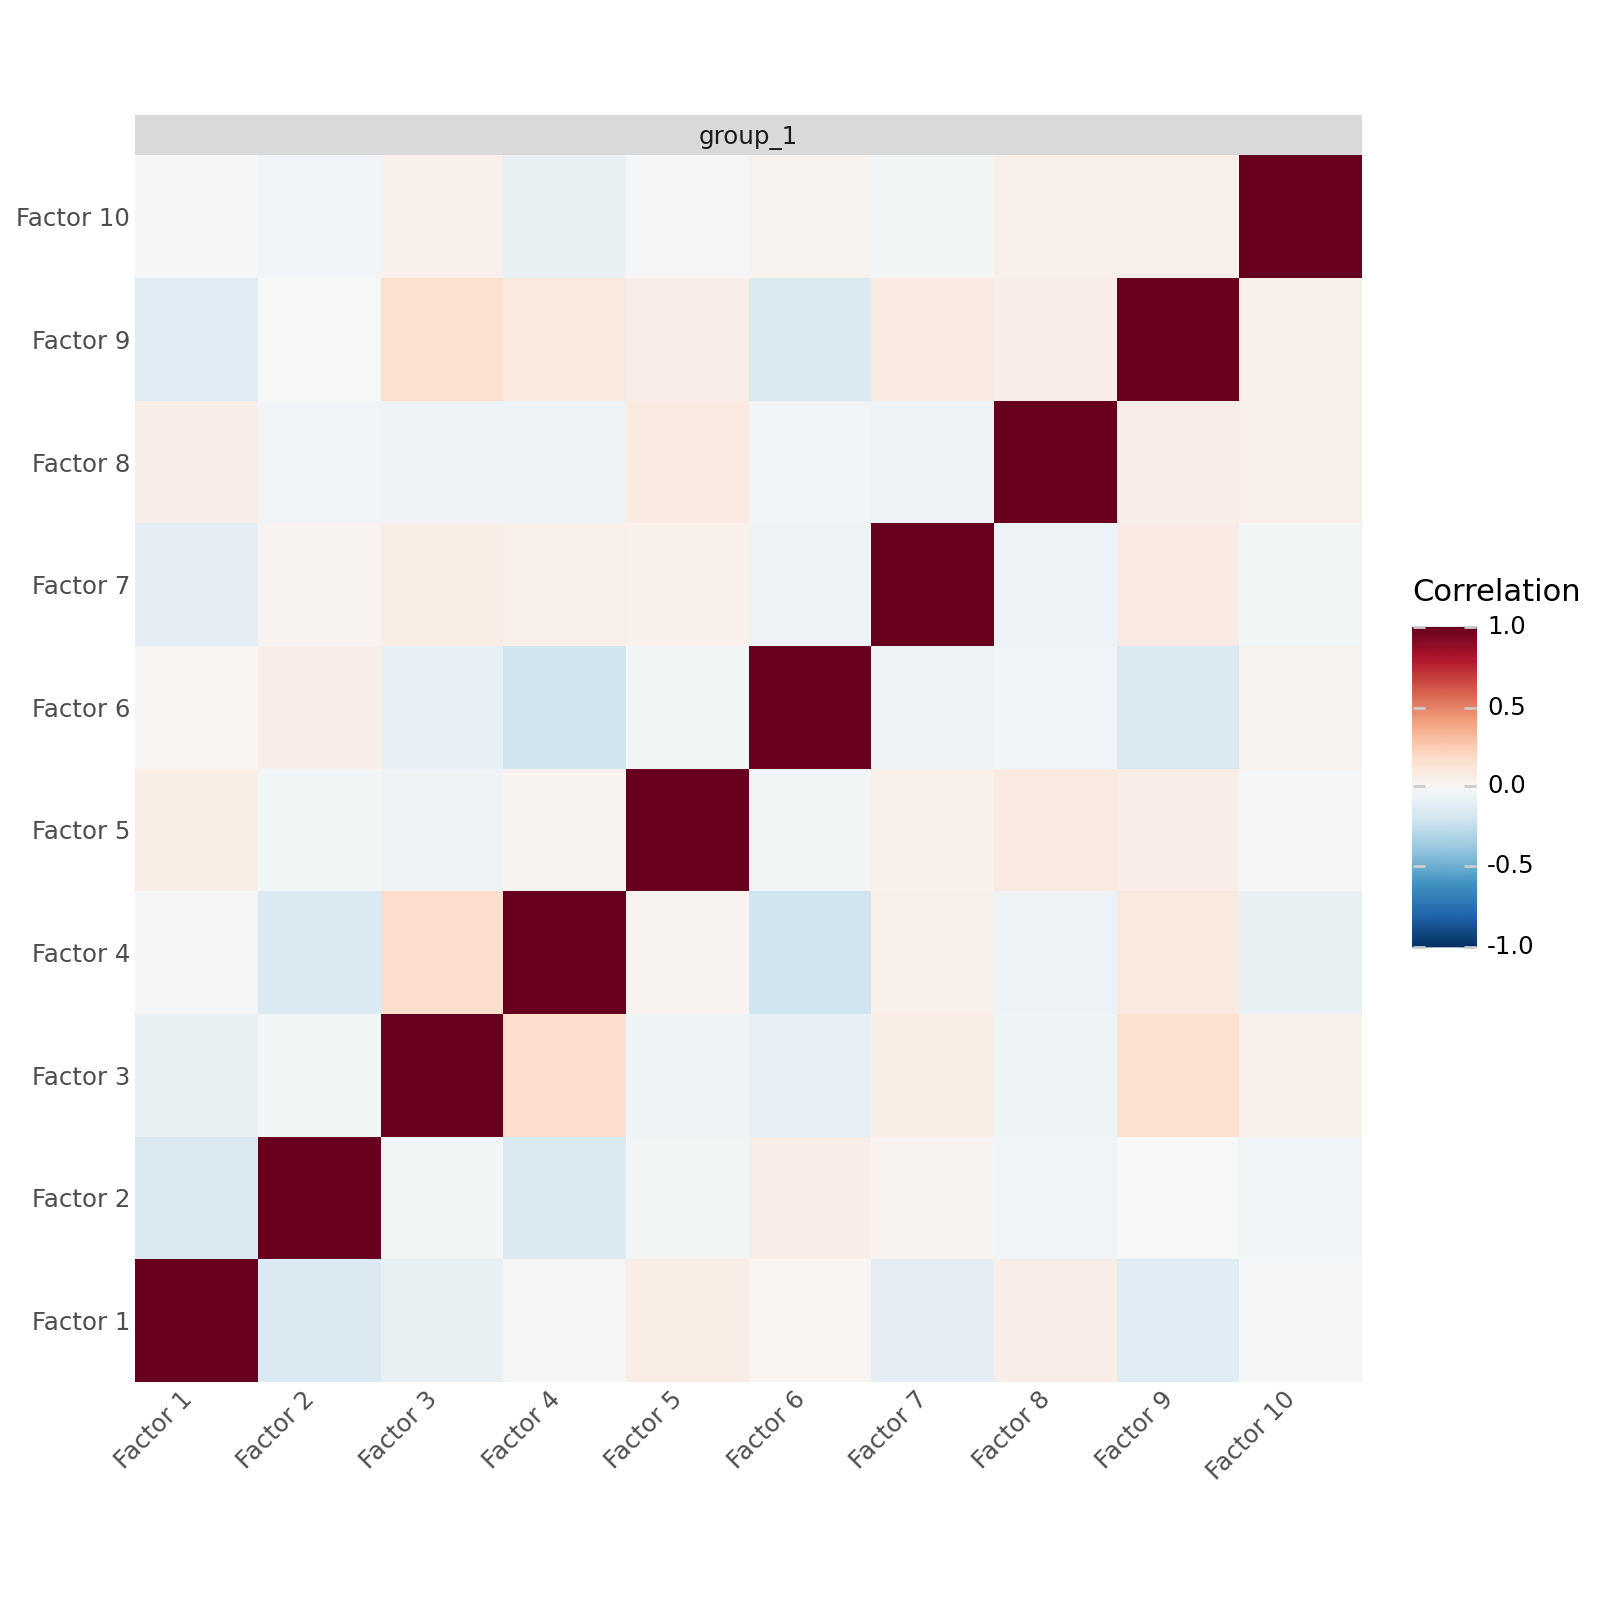

In [121]:
mfl.pl.factor_correlation(model)

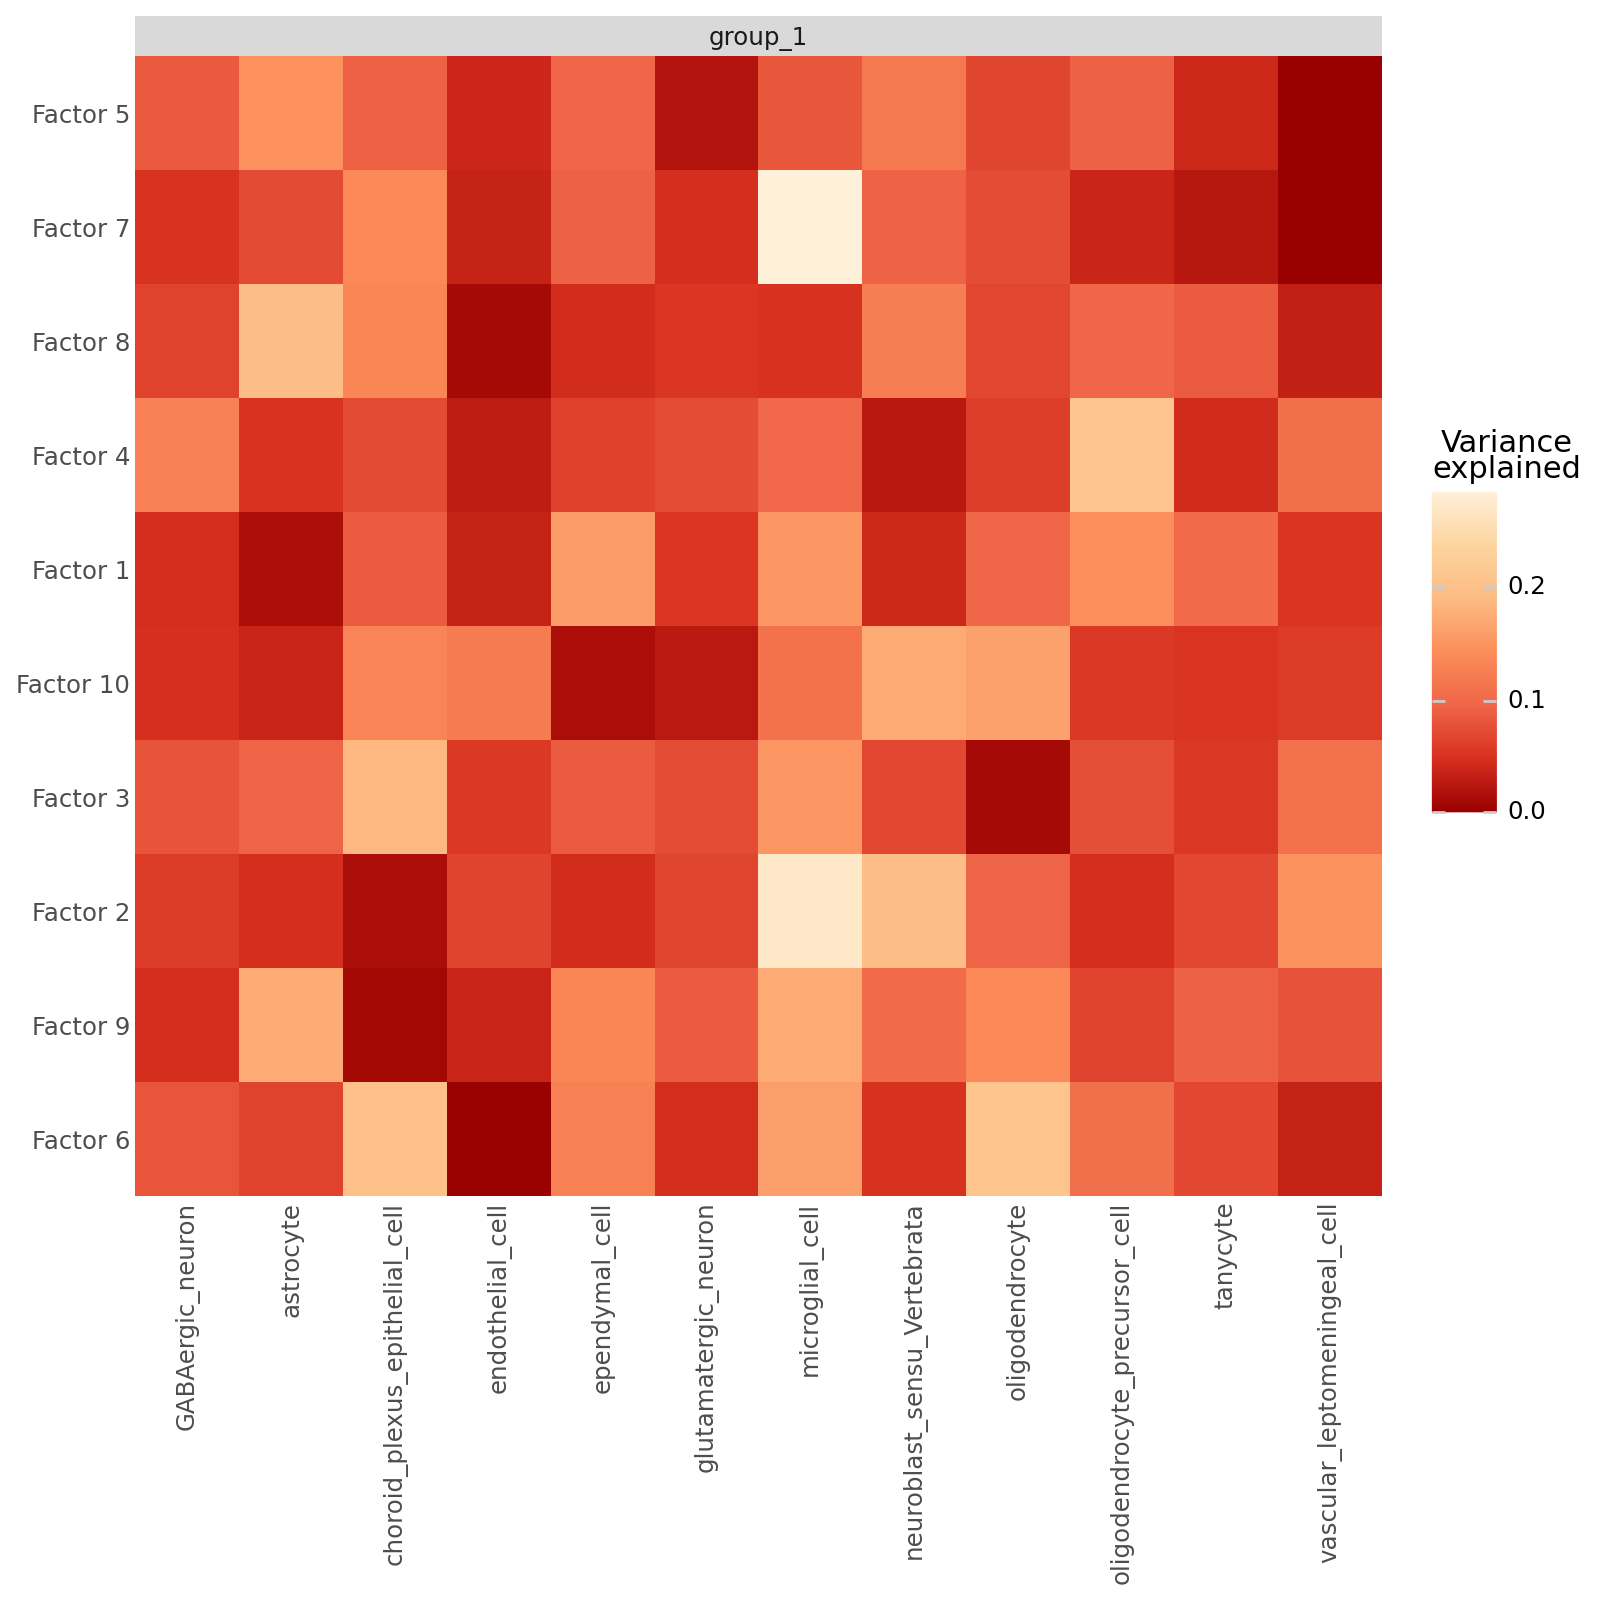

In [122]:
mfl.pl.variance_explained(model, figsize= (8,8))

## 2. Average R2

In [123]:
print(model.get_r2(total=True))

                                 group_1
glutamatergic_neuron            0.502410
tanycyte                        0.681551
neuroblast_sensu_Vertebrata     0.855801
GABAergic_neuron                0.680113
ependymal_cell                  0.911942
vascular_leptomeningeal_cell    0.824173
microglial_cell                 0.999997
choroid_plexus_epithelial_cell  0.852495
oligodendrocyte_precursor_cell  0.954915
astrocyte                       0.716429
oligodendrocyte                 0.912912
endothelial_cell                0.556929


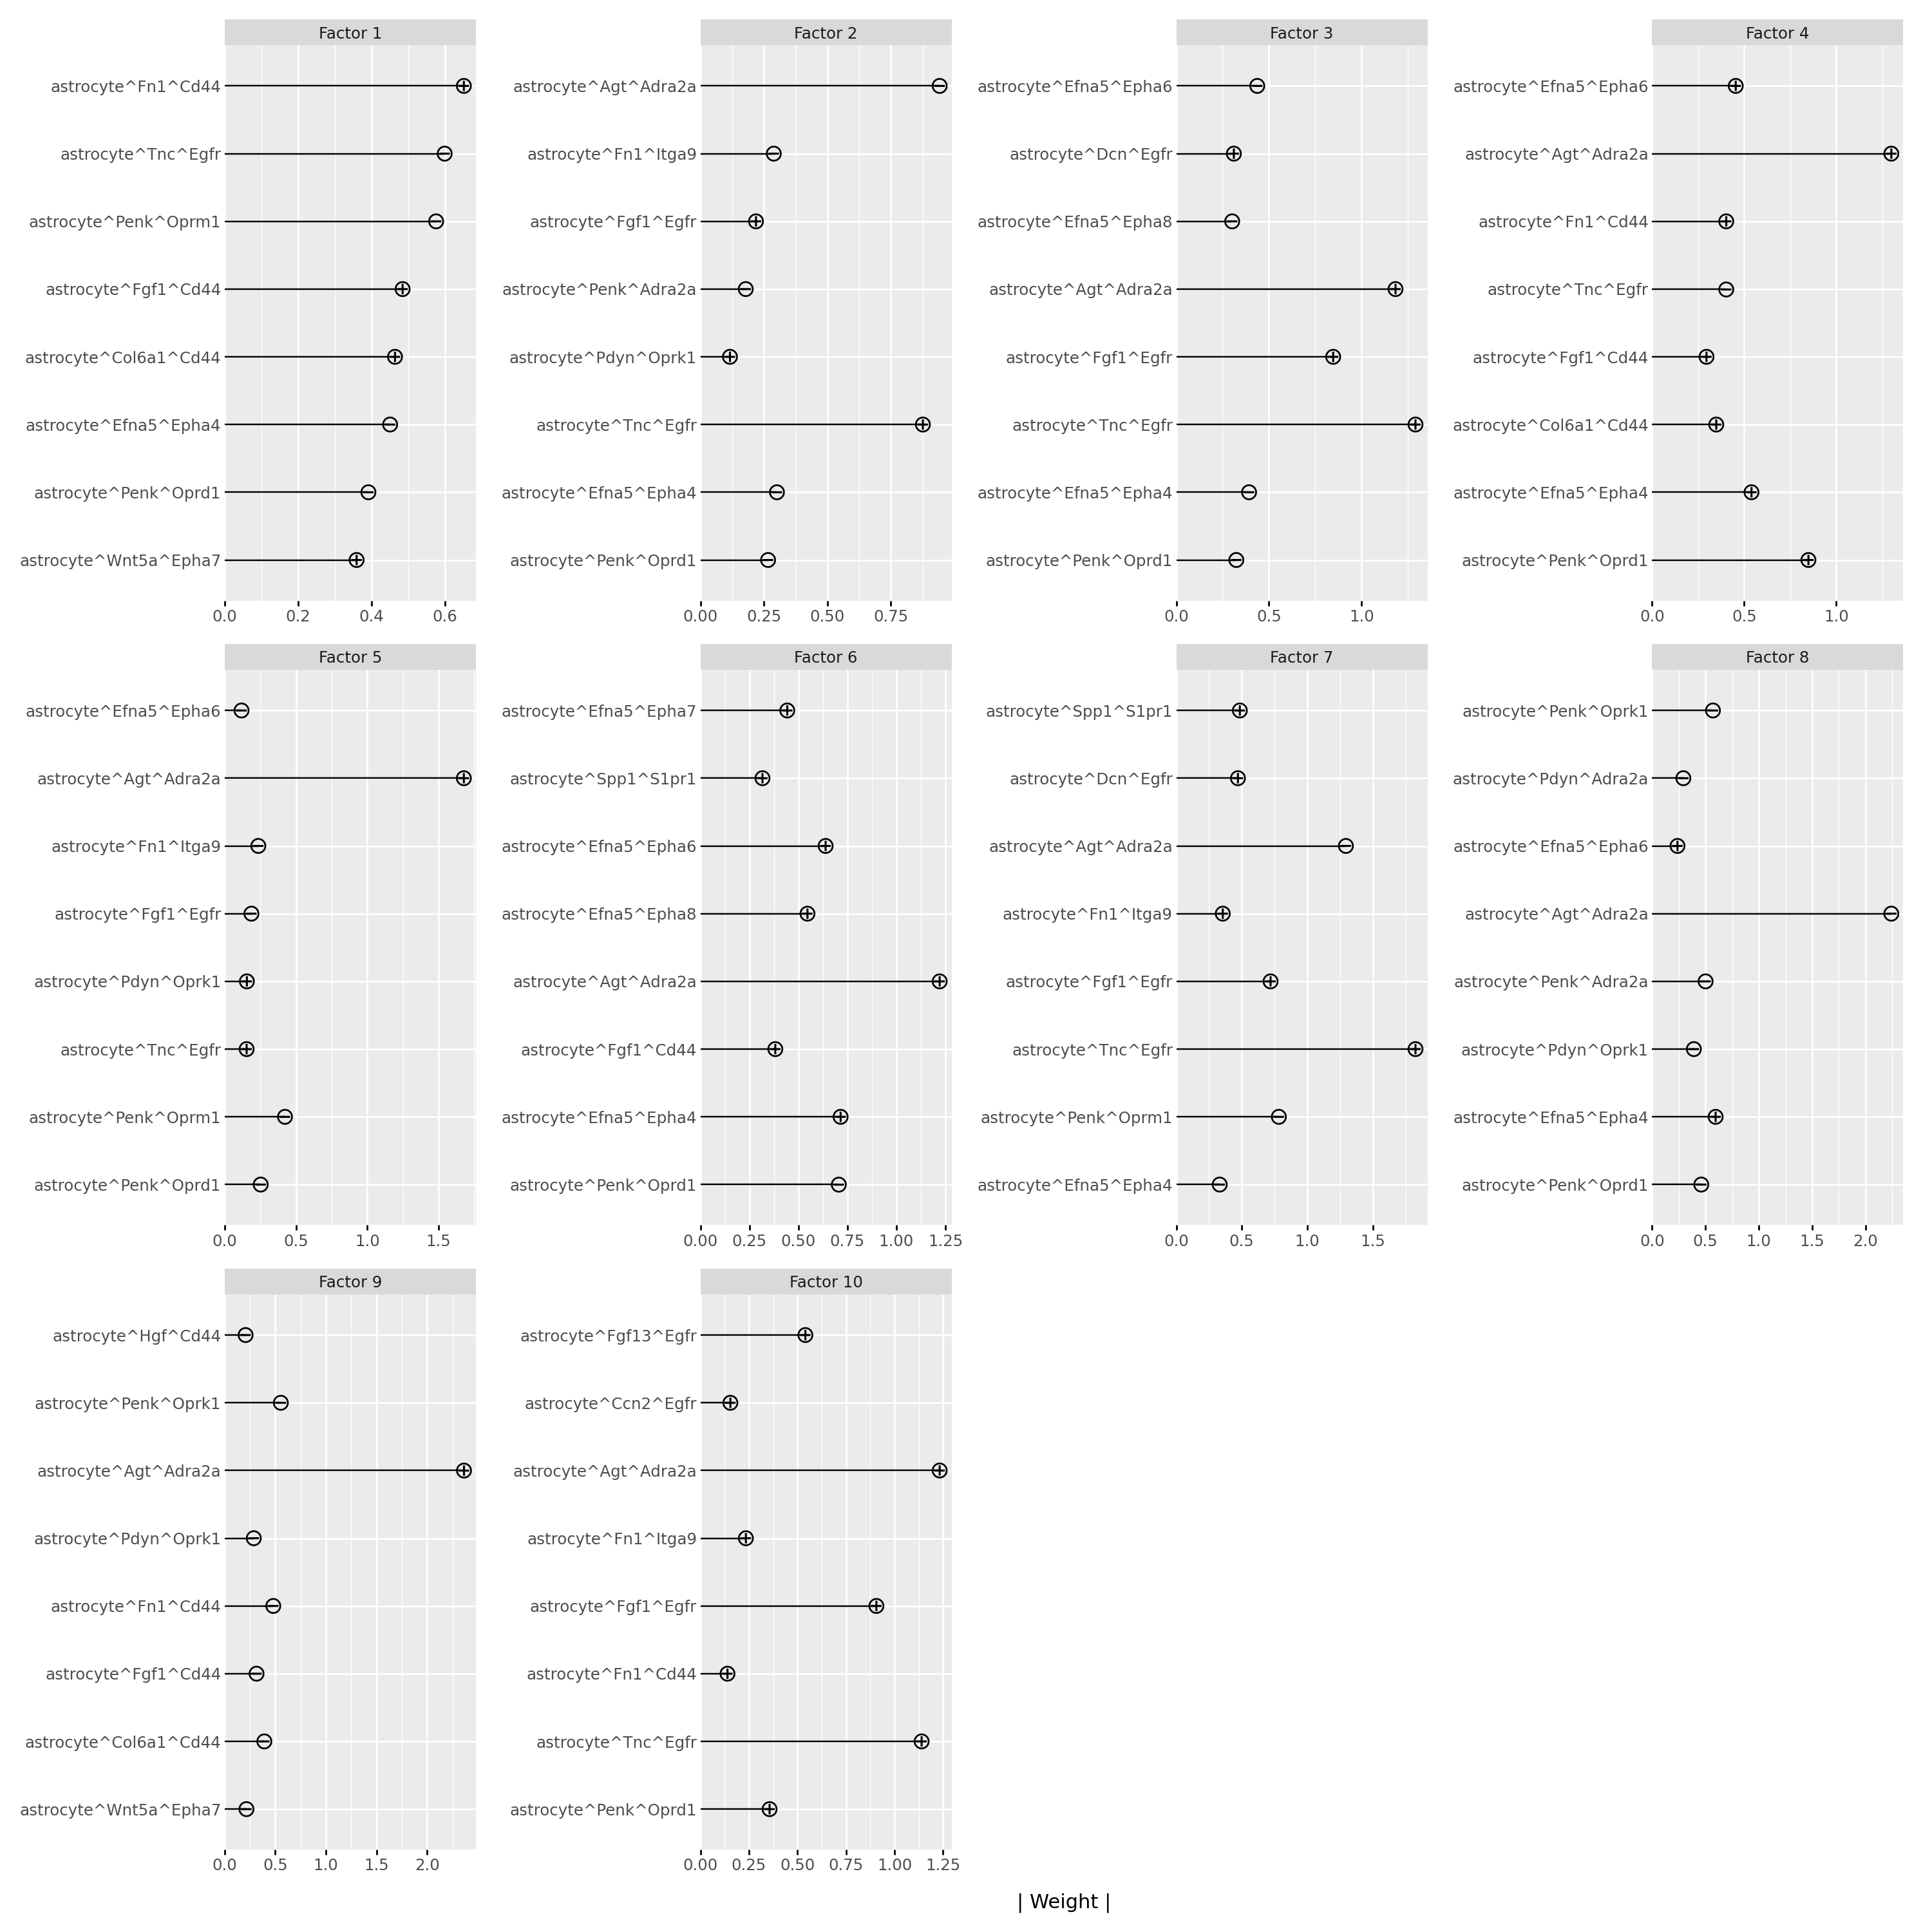

In [318]:
mfl.pl.top_weights(model, n_features=8, views="astrocyte", factors=None, figsize=(15, 15), nrow=None, ncol=None)

In [270]:
factors = model.get_factors()
factors = factors["group_1"]

In [ ]:
lrdata.obs.index

In [ ]:
factors = factors.reindex(lrdata.obs.index)
factors

In [322]:
lrdata.obs["factor6"] = factors["Factor 6"]

In [323]:
lrdata

AnnData object with n_obs × n_vars = 51545 × 1360
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'F_Cluster', 'Cluster', 'factor7', 'factor8', 'factor9', 'factor10', 'factor5', 'factor3', 'factor6'
    uns: 'citation', 'moranI', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'F_Cluster_colors', 'Cluster_colors', 'cell_type_colors', 'tissue_colors'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'
    lay

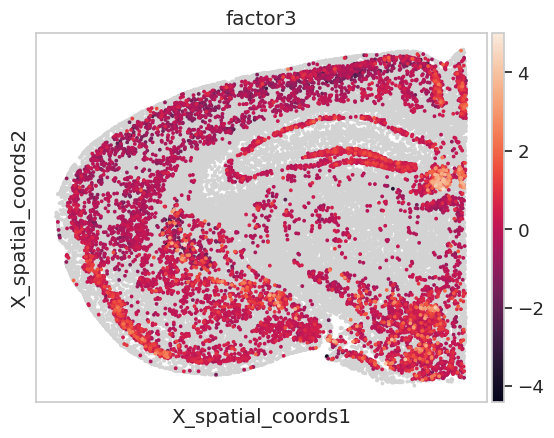

In [324]:
sc.pl.embedding(lrdata, basis="X_spatial_coords", color="factor3", s=30)  

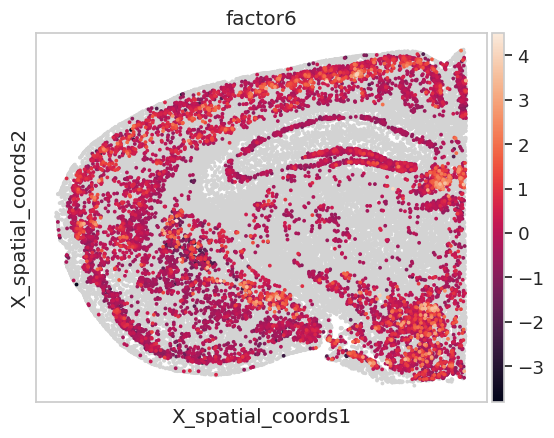

In [325]:
sc.pl.embedding(lrdata, basis="X_spatial_coords", color="factor6", s=30)  

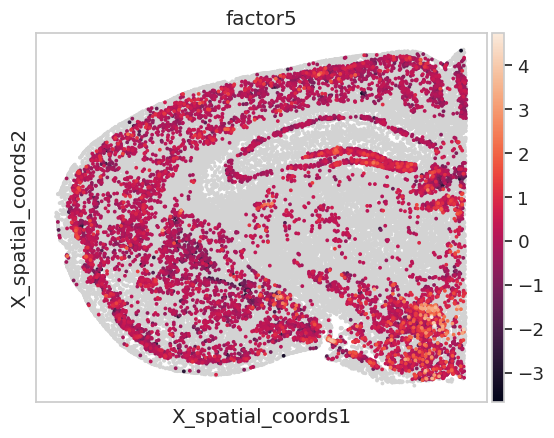

In [292]:
sc.pl.embedding(lrdata, basis="X_spatial_coords", color="factor5", s=30)  

/scratch/jobs/38879061/ipykernel_14419/1360243266.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


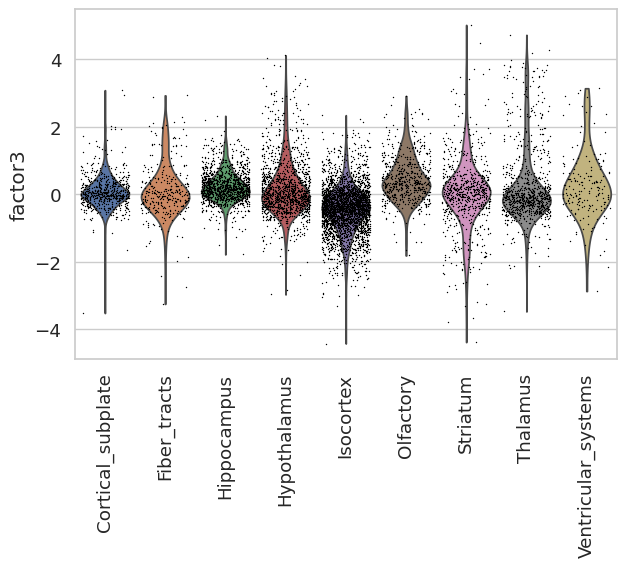

In [335]:
import scanpy as sc
import matplotlib.pyplot as plt

sc.pl.violin(
    lrdata,
    keys='factor3',
    groupby='major_brain_region',
    rotation=90,
    stripplot=True,
    jitter=0.4,
    multi_panel=False,
    show=False,       # allows you to modify before display
    legend=False      # disables the legend
)

plt.tight_layout()
plt.show()


/scratch/jobs/38879061/ipykernel_14419/1060763743.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


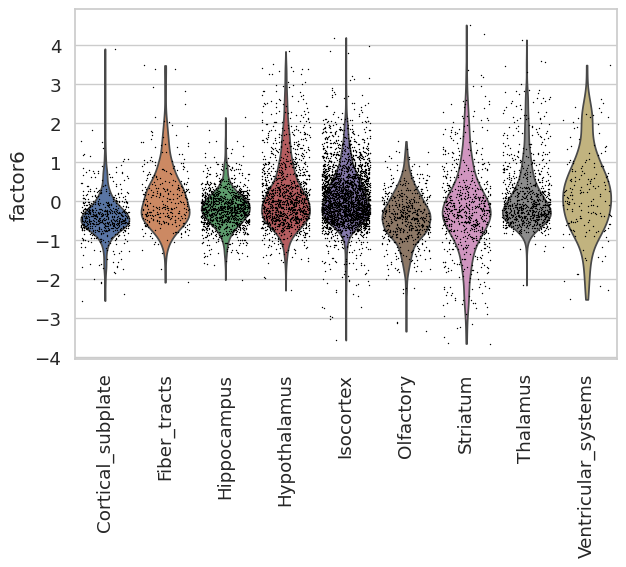

In [336]:
import scanpy as sc
import matplotlib.pyplot as plt

sc.pl.violin(
    lrdata,
    keys='factor6',
    groupby='major_brain_region',
    rotation=90,
    stripplot=True,
    jitter=0.4,
    multi_panel=False,
    show=False,       # allows you to modify before display
    legend=False      # disables the legend
)

plt.tight_layout()
plt.show()


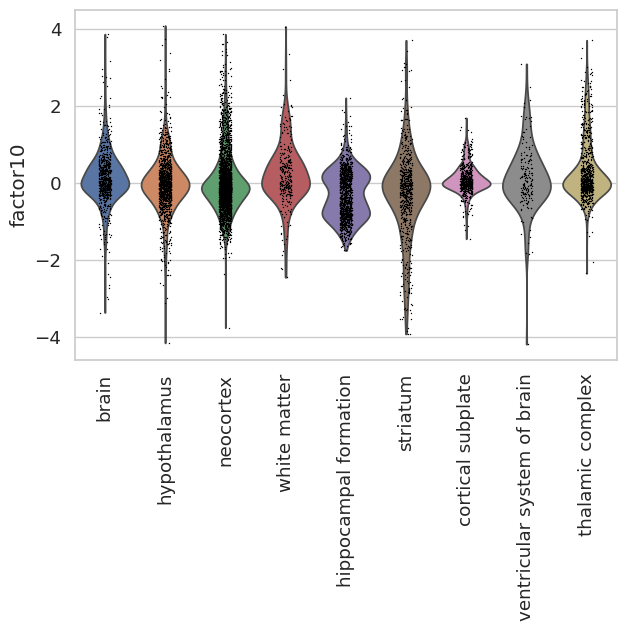

In [314]:
sc.pl.violin(
    lrdata,
    keys='factor10',
    groupby='tissue',
    rotation=90,
)

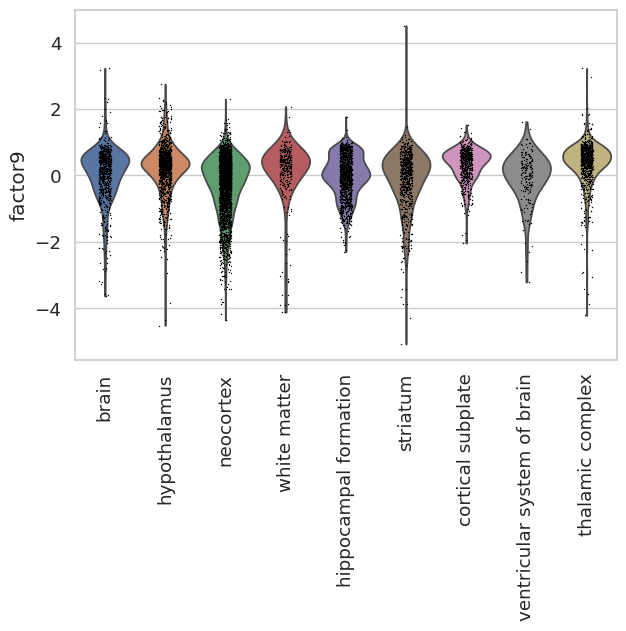

In [316]:
sc.pl.violin(
    lrdata,
    keys='factor9',
    groupby='tissue',
    rotation=90,
)

In [124]:
r2 = model.get_r2(total=True)
r2["group_1"].mean()

np.float64(0.7874722988052829)

In [187]:
model

In [199]:
weights_dict= model.get_weights()

In [257]:
keys_to_keep = ["astrocyte"]

subset = {k: weights_dict[k] for k in keys_to_keep if k in weights_dict}


In [261]:
df = subset['astrocyte']
df

,astrocyte^Ntf3^Ntrk3,astrocyte^Gnb3^Gabbr2,astrocyte^Efna5^Epha4,astrocyte^Nts^Ntsr2,astrocyte^Spp1^S1pr1,astrocyte^Sfrp1^Fzd2,astrocyte^Efna5^Epha10,astrocyte^Efna5^Ephb1,astrocyte^Sostdc1^Lrp4,astrocyte^Tnc^Egfr,...,astrocyte^Wnt5a^Fzd5,astrocyte^Efna5^Epha3,astrocyte^Penk^Oprk1,astrocyte^Fn1^Itga9,astrocyte^Rspo1^Lgr5,astrocyte^Hgf^Cd44,astrocyte^Col6a1^Cd44,astrocyte^Fgf1^Cd44,astrocyte^Vcan^Cd44,astrocyte^Fn1^Cd44
Factor 1,0.082052,1.805620e-06,-4.511478e-01,-0.033169,-0.132113,-0.118077,-0.277026,-0.062198,2.926208e-06,-0.599878,...,-0.000007,1.642950e-06,-2.547175e-01,-0.202279,1.633341e-05,2.840772e-01,4.644763e-01,0.485189,0.000005,0.652169
Factor 2,-0.021368,-6.454657e-06,-3.012388e-01,0.000028,-0.000090,0.073500,-0.000036,-0.000001,3.080140e-07,0.875967,...,0.000002,-6.990570e-06,3.704475e-06,-0.288789,-1.413159e-06,5.793216e-03,-4.740192e-06,-0.061038,-0.000001,0.000323
Factor 3,-0.013599,8.347997e-08,-3.927236e-01,0.118478,0.278145,0.155195,-0.190003,-0.077663,-2.303324e-06,1.290728,...,0.000002,2.886051e-02,-2.173776e-01,0.100629,-3.722378e-02,7.339370e-02,8.677198e-02,-0.000100,0.000002,0.096928
Factor 4,-0.000008,-3.852907e-06,5.398790e-01,0.007121,-0.115525,-0.085025,0.291955,0.123036,4.133753e-06,-0.400973,...,-0.000001,6.109967e-02,3.276893e-02,-0.220603,-4.600058e-02,1.803696e-01,3.485995e-01,0.295486,-0.000003,0.402791
Factor 5,0.000007,-3.361827e-07,-1.060570e-01,-0.046109,-0.110658,-0.058210,0.000013,-0.000006,4.348586e-06,0.154203,...,-0.000006,8.173373e-06,8.741135e-02,-0.236203,-6.663552e-06,-1.881029e-07,-2.683134e-02,-0.091131,0.000004,-0.000018
Factor 6,0.000013,-1.651900e-06,7.152015e-01,0.009840,0.316460,0.000027,0.000074,-0.000086,-5.321879e-06,-0.306814,...,0.000011,1.358864e-05,4.891115e-07,0.281286,3.603657e-06,-1.078133e-05,6.703601e-06,0.382013,-0.000008,0.000007
Factor 7,0.000006,-2.004830e-06,-3.314636e-01,-0.000057,0.485361,0.233910,-0.088178,-0.000011,-2.286349e-08,1.825953,...,-0.000002,-1.810023e-05,-1.689847e-01,0.355046,-1.093983e-05,7.889728e-02,3.869655e-02,0.111406,0.000001,0.120016
Factor 8,-0.000023,1.939683e-06,5.950380e-01,-0.051714,-0.132756,-0.080151,0.046795,0.000015,5.510120e-07,-0.047094,...,-0.000006,1.255252e-01,-5.700454e-01,-0.137697,7.595364e-08,3.837746e-02,-5.222631e-07,0.205119,0.000009,-0.000017
Factor 9,-0.000004,-4.036351e-02,-6.241576e-07,-0.000011,0.000004,-0.002339,-0.091322,-0.000034,-1.623104e-06,0.146615,...,0.000003,-5.012283e-07,-5.551156e-01,-0.057117,5.419762e-06,-2.069956e-01,-3.923162e-01,-0.315374,-0.000007,-0.480339
Factor 10,-0.052481,-5.539828e-02,-2.641945e-06,0.060173,0.007467,0.123592,0.000264,0.000001,2.421330e-06,1.139700,...,-0.000026,4.231227e-08,-2.573339e-06,0.234180,1.032822e-06,7.977818e-02,1.096286e-01,-0.005532,-0.000004,0.139279


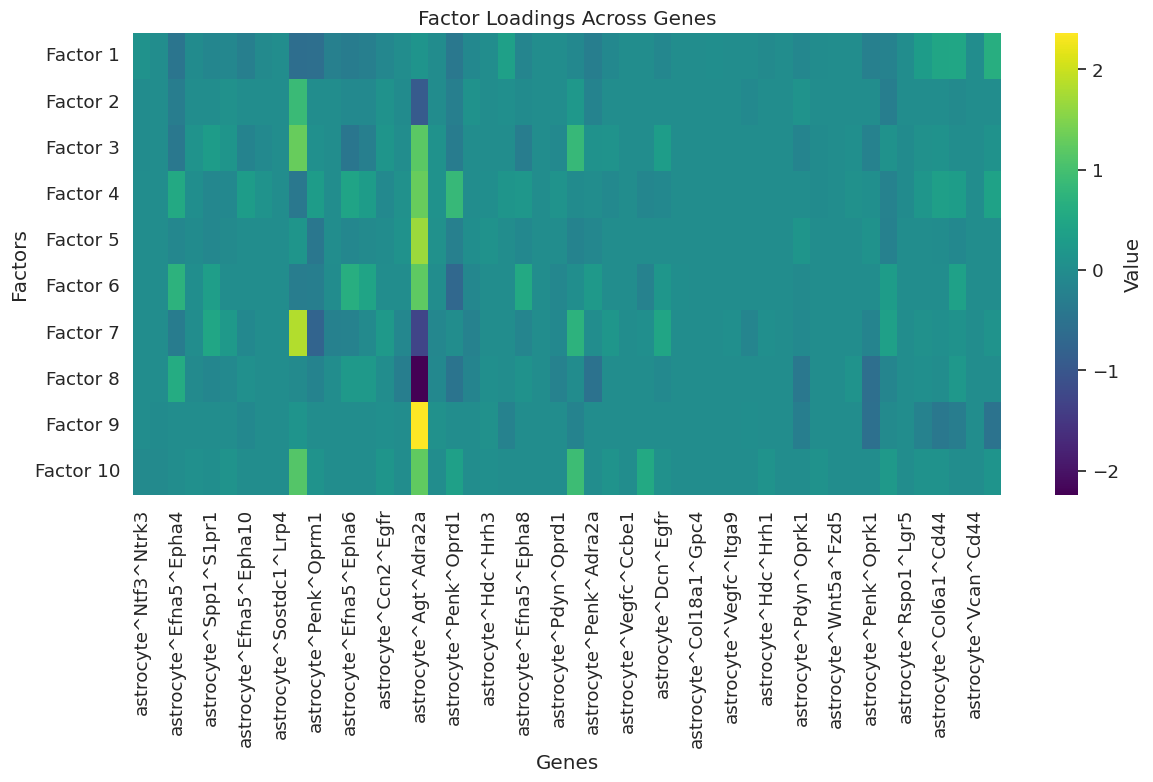

In [263]:
import matplotlib.pyplot as plt
import seaborn as sns  # optional, but great for heatmaps

plt.figure(figsize=(14, 6))
sns.heatmap(df, cmap="viridis", cbar_kws={'label': 'Value'})
plt.xlabel("Genes")
plt.ylabel("Factors")
plt.title("Factor Loadings Across Genes")
plt.show()


<Figure size 1400x800 with 0 Axes>

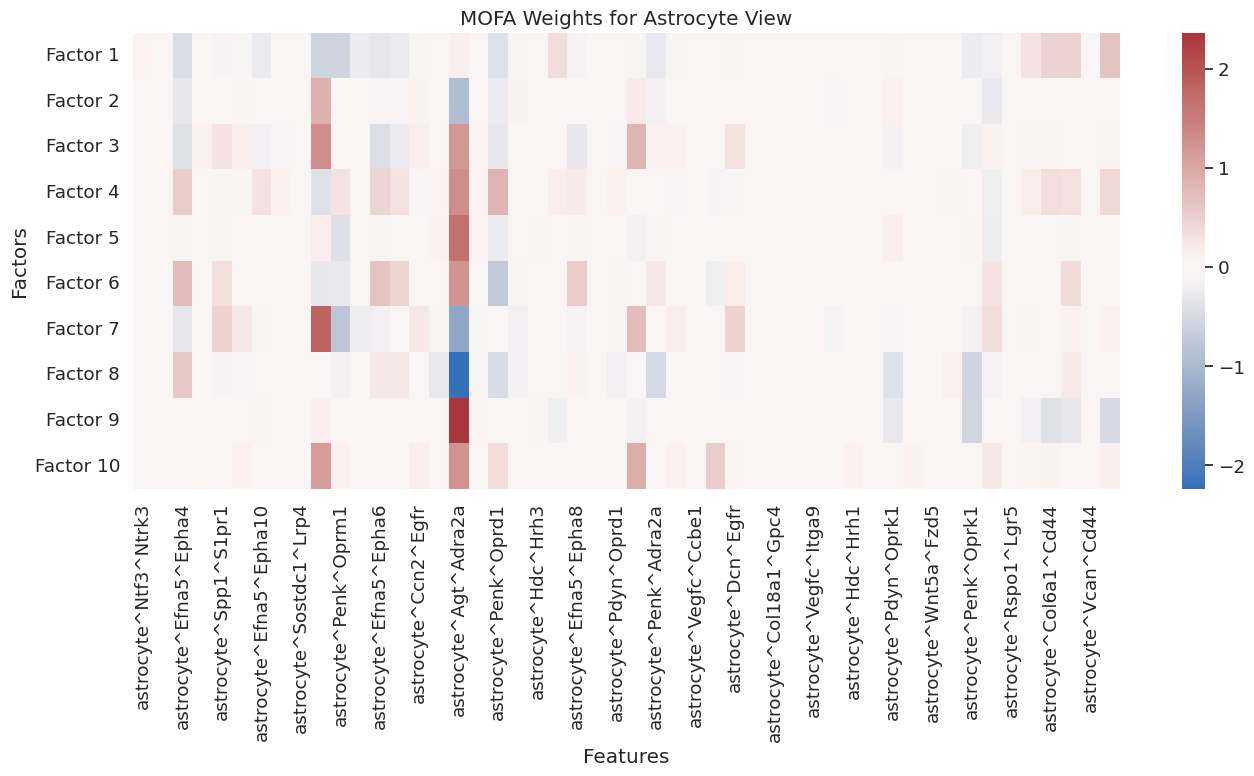

In [259]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.heatmap(df, cmap="vlag", center=0)
plt.title("MOFA Weights for Astrocyte View")
plt.xlabel("Features")
plt.ylabel("Factors")
plt.tight_layout()
plt.show()


In [250]:
factors = model.get_factors()
factors = factors["group_1"]

In [251]:
cell_types = lrdata.obs["cell_type"]
#tissue = lrdata.obs["tissue"]

In [252]:
df = factors.copy()
df['cell_type'] = cell_types
#df['tissue'] = tissue

In [253]:
df_melted = df.reset_index().melt(
    id_vars=['index', "cell_type"],
    value_vars=[f'Factor {i}' for i in range(1, 11)],
    var_name='Factor',
    value_name='Value'
)

In [254]:
df_melted

,index,cell_type,Factor,Value
0,12185986486062748399642964467627918512,glutamatergic neuron,Factor 1,-0.267860
1,56898090918706268322480378279645296213,glutamatergic neuron,Factor 1,0.116429
2,120259415432447893517416781425739794741,GABAergic neuron,Factor 1,1.336947
3,62415733978122634249512061004080784872,glutamatergic neuron,Factor 1,1.362108
4,102093083336931440857879796934957752261,glutamatergic neuron,Factor 1,1.827404
...,...,...,...,...
93795,300543435981200758297044048836374706712,GABAergic neuron,Factor 10,0.372146
93796,312945673217699486459993049617980646276,glutamatergic neuron,Factor 10,-0.545570
93797,116344495286861894462157516420223807276,vascular leptomeningeal cell,Factor 10,-0.307079
93798,17582231177180709444320157527078380982,astrocyte,Factor 10,-0.063481


/scratch/jobs/38879061/ipykernel_14419/1520418314.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


<Figure size 1400x600 with 0 Axes>

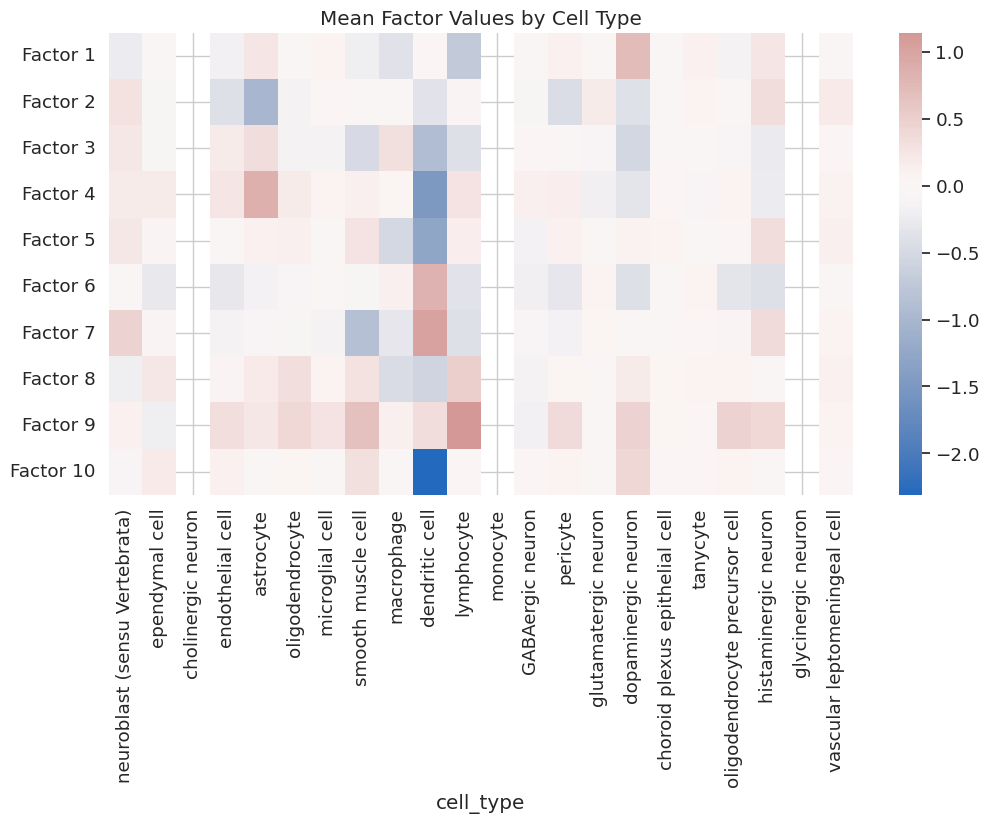

In [255]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mean factor values per cell type
mean_factors = df.groupby('cell_type').mean().T

plt.figure(figsize=(12, 6))
sns.heatmap(mean_factors, cmap='vlag', center=0)
plt.title('Mean Factor Values by Cell Type')
plt.show()


/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
/scratch/jobs/38879061/ipykernel_14419/91744081.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/scratch/jobs/38879061/ipykernel_14419/91744081.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


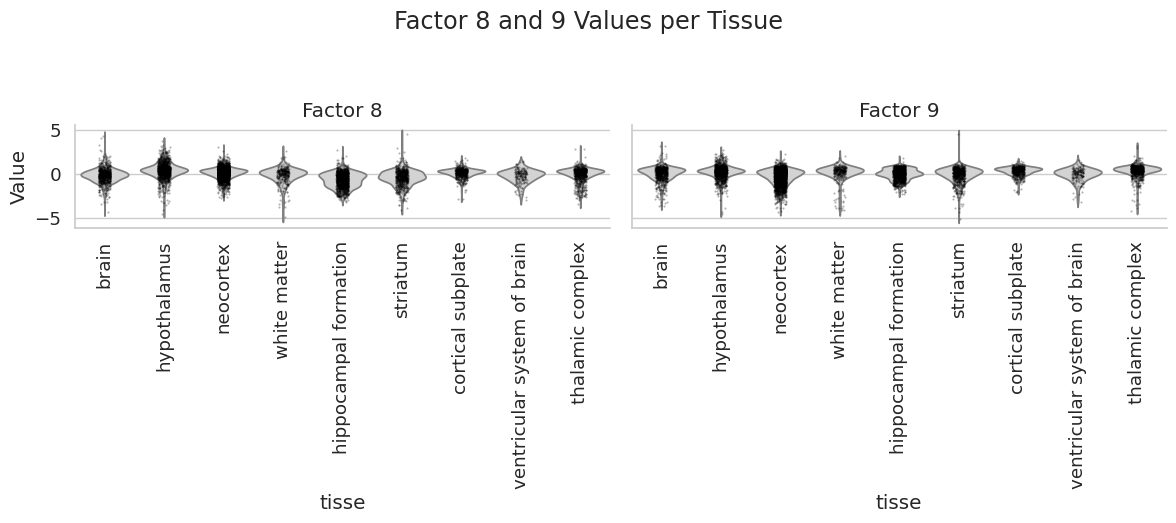

In [231]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to just Factor 8 and Factor 9
subset = df_melted[df_melted['Factor'].isin(['Factor 8', 'Factor 9'])]

# Create side-by-side plots (1 row, 2 columns)
g = sns.FacetGrid(subset, col='Factor', sharey=True, height=5, aspect=1.2)

# Add violin + strip overlay
g.map_dataframe(
    sns.violinplot,
    x='tisse', y='Value',
    inner=None, scale='width',
    color='lightgray'
)
g.map_dataframe(
    sns.stripplot,
    x='tisse', y='Value',
    color='black', size=1.5, jitter=True, alpha=0.3
)

g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.suptitle("Factor 8 and 9 Values per Tissue", y=1.05)
plt.tight_layout()
plt.show()


In [249]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Keep only Factor 8 and 9 and normalize labels
subset = df_melted[df_melted["Factor"].isin(["Factor 8", "Factor 9", "F8", "F9", 8, 9])].copy()
subset["Factor_norm"] = subset["Factor"].replace({
    "F8": "Factor 8", "F9": "Factor 9", 8: "Factor 8", 9: "Factor 9"
})

# Optional: control order on x and in legend
# tissue_order = sorted(subset["tisse"].unique())
# factor_order = ["Factor 8", "Factor 9"]

plt.figure(figsize=(14, 6))

# Side-by-side violins per tissue (dodge=True)
sns.violinplot(
    data=subset,
    x="tisse",
    y="Value",
    hue="Factor_norm",
    dodge=True,
    inner=None,       # cleaner violins; change to "quartile" if you want quartile lines
    scale="width",
    cut=0,            # avoid tails beyond data
    # order=tissue_order,
    # hue_order=factor_order,
)

# Overlay individual points; use same hue + dodge so dots line up with each violin
sns.stripplot(
    data=subset,
    x="tisse",
    y="Value",
    hue="Factor_norm",
    dodge=True,
    jitter=True,
    size=1.5,
    alpha=0.35,
    color="black",    # one color for points; we'll keep the legend from the violins
    # order=tissue_order,
    # hue_order=factor_order,
    legend=False      # prevent duplicate legend
)

plt.xticks(rotation=90)
plt.xlabel("Tissue")
plt.ylabel("Value")
plt.title("Factor 8 vs Factor 9 per Tissue")

# Keep only one legend (from the violinplot); move it outside if crowded
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Factor", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


ValueError: Could not interpret value `tisse` for `x`. An entry with this name does not appear in `data`.

/scratch/jobs/38879061/ipykernel_14419/3427058440.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.


<Figure size 1400x600 with 0 Axes>

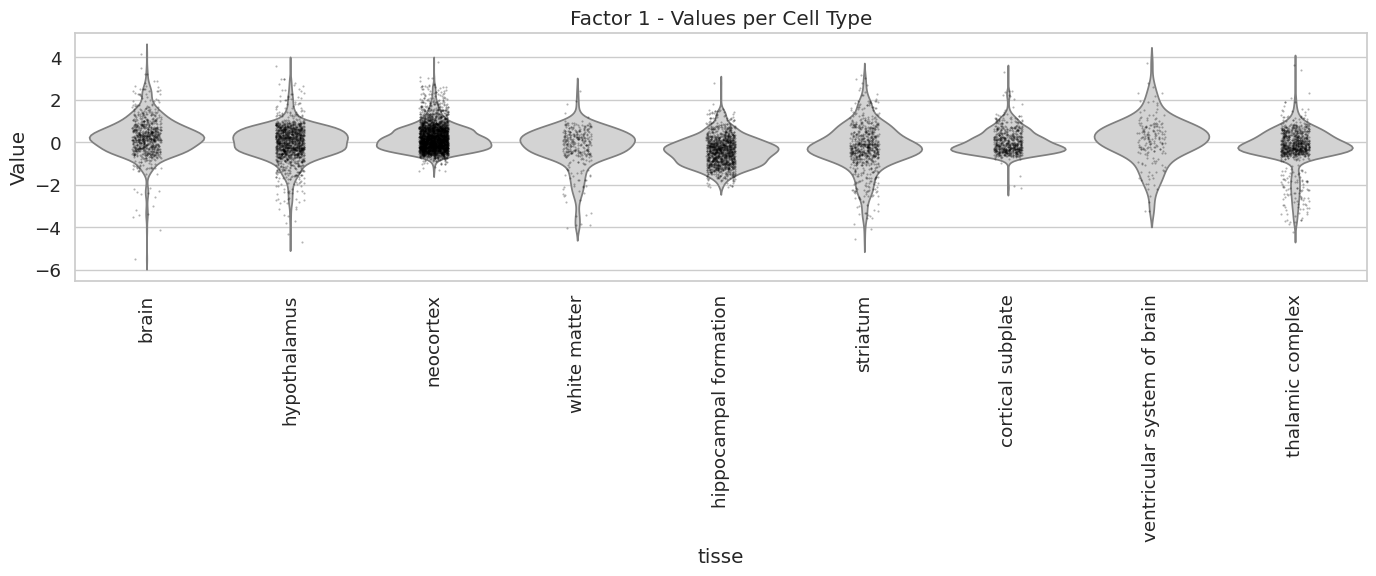

/scratch/jobs/38879061/ipykernel_14419/3427058440.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.


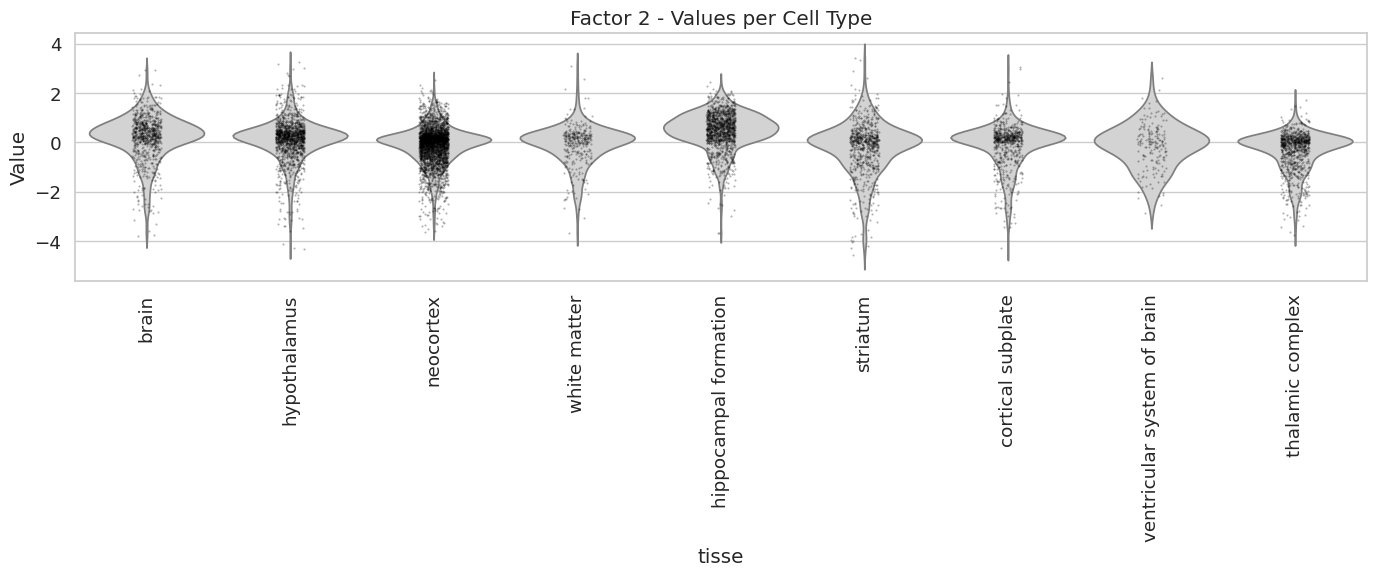

/scratch/jobs/38879061/ipykernel_14419/3427058440.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.


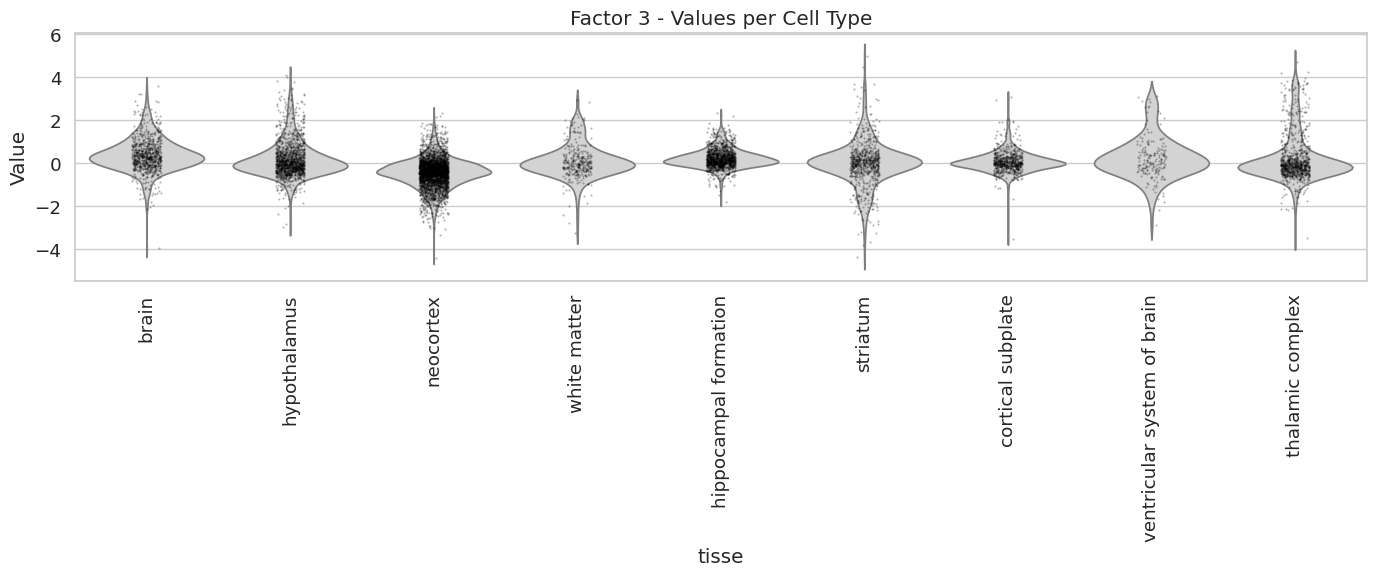

/scratch/jobs/38879061/ipykernel_14419/3427058440.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.


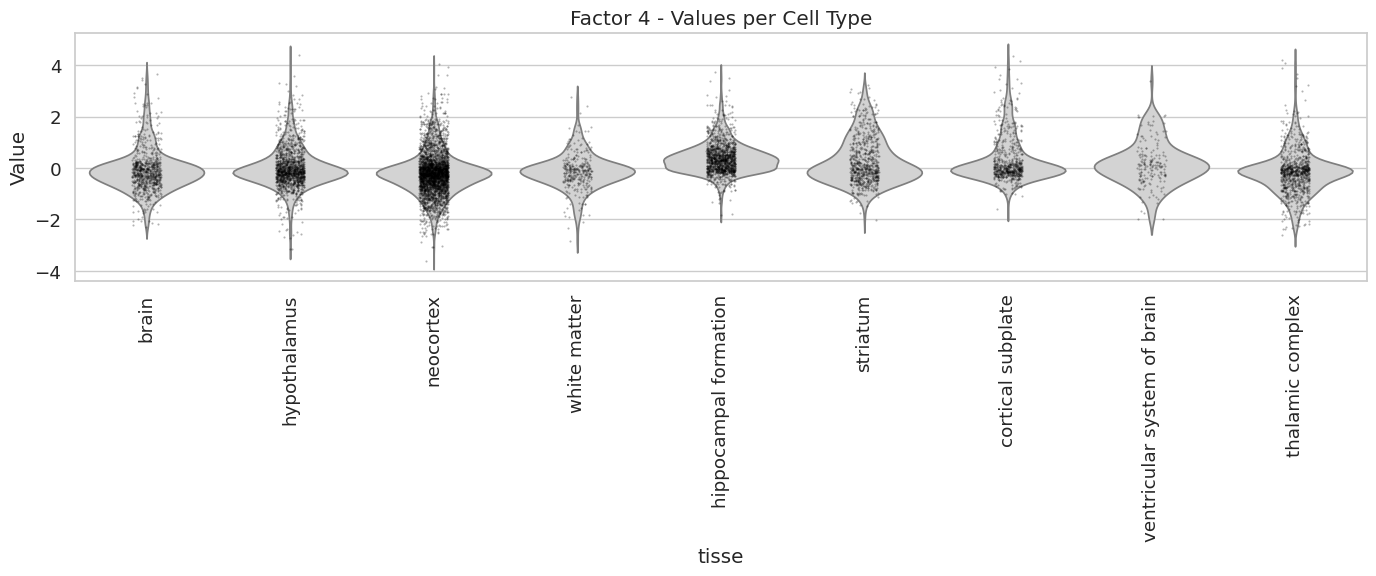

/scratch/jobs/38879061/ipykernel_14419/3427058440.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.


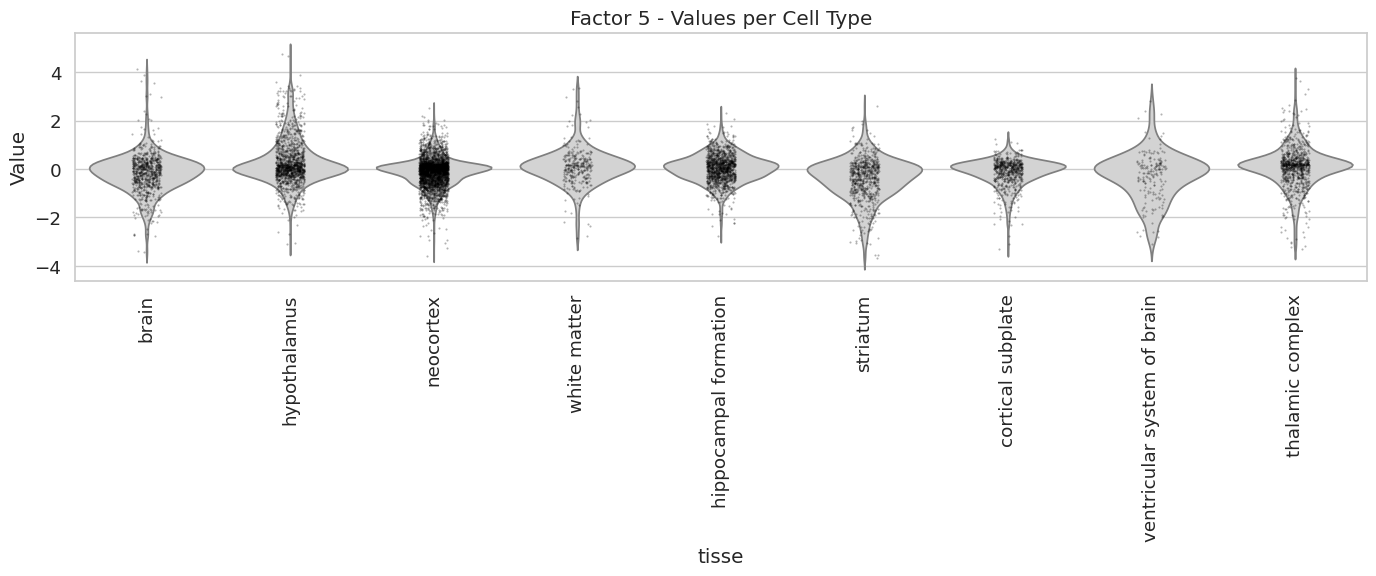

/scratch/jobs/38879061/ipykernel_14419/3427058440.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.


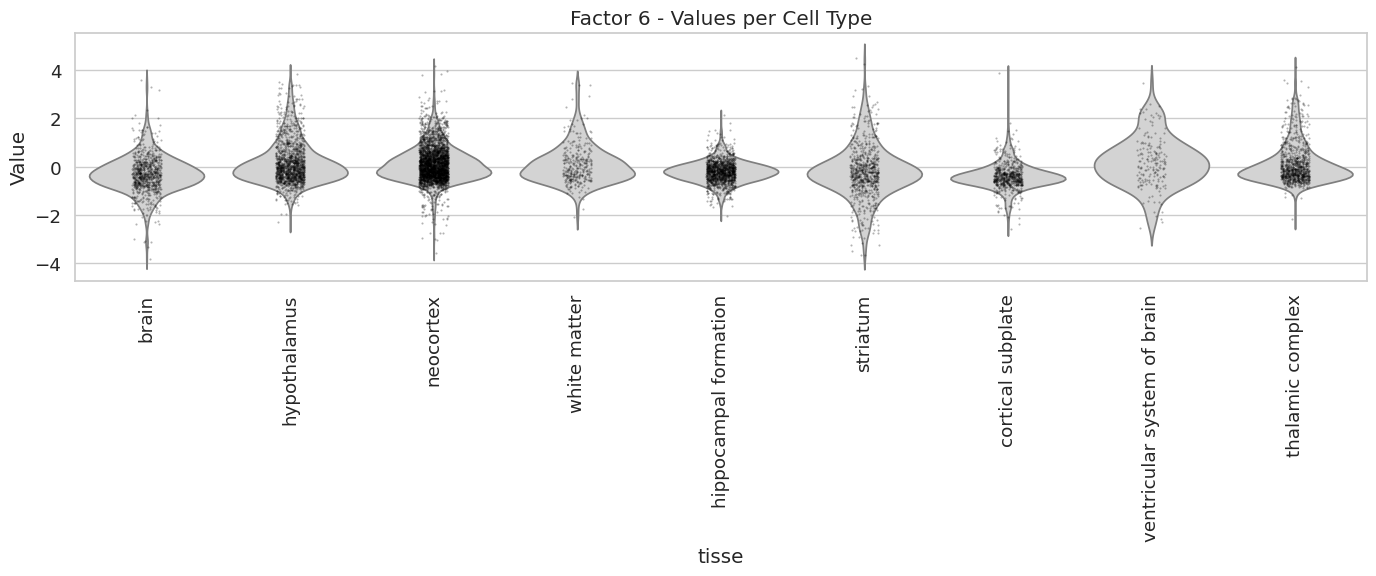

/scratch/jobs/38879061/ipykernel_14419/3427058440.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.


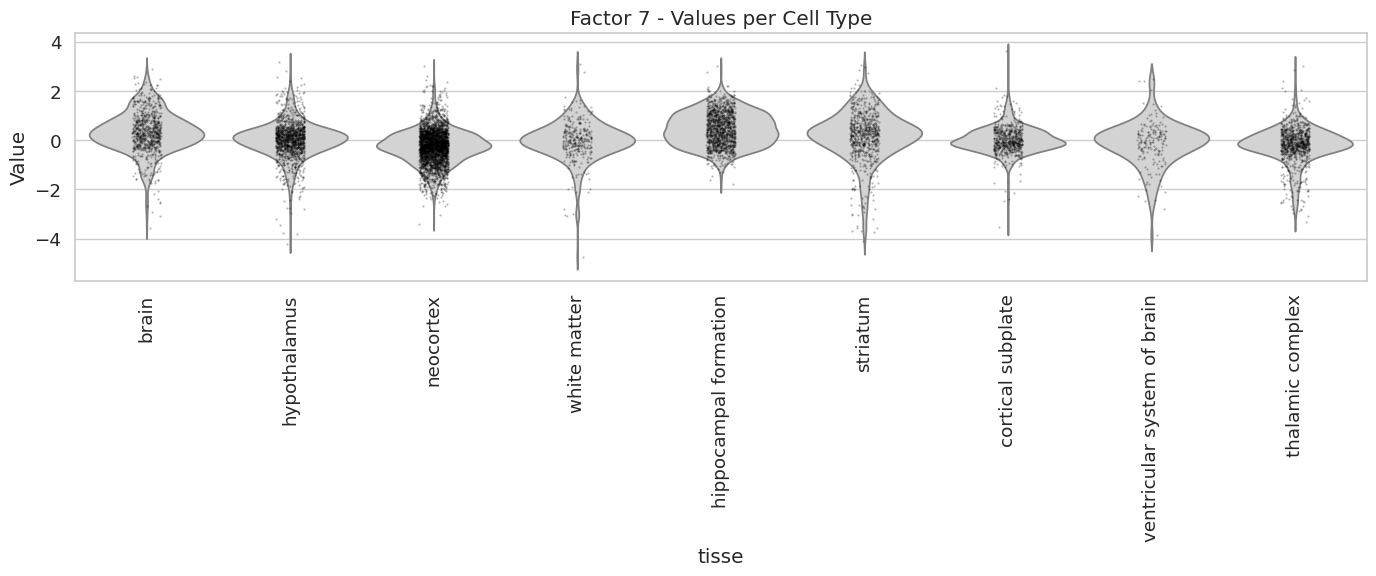

/scratch/jobs/38879061/ipykernel_14419/3427058440.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.


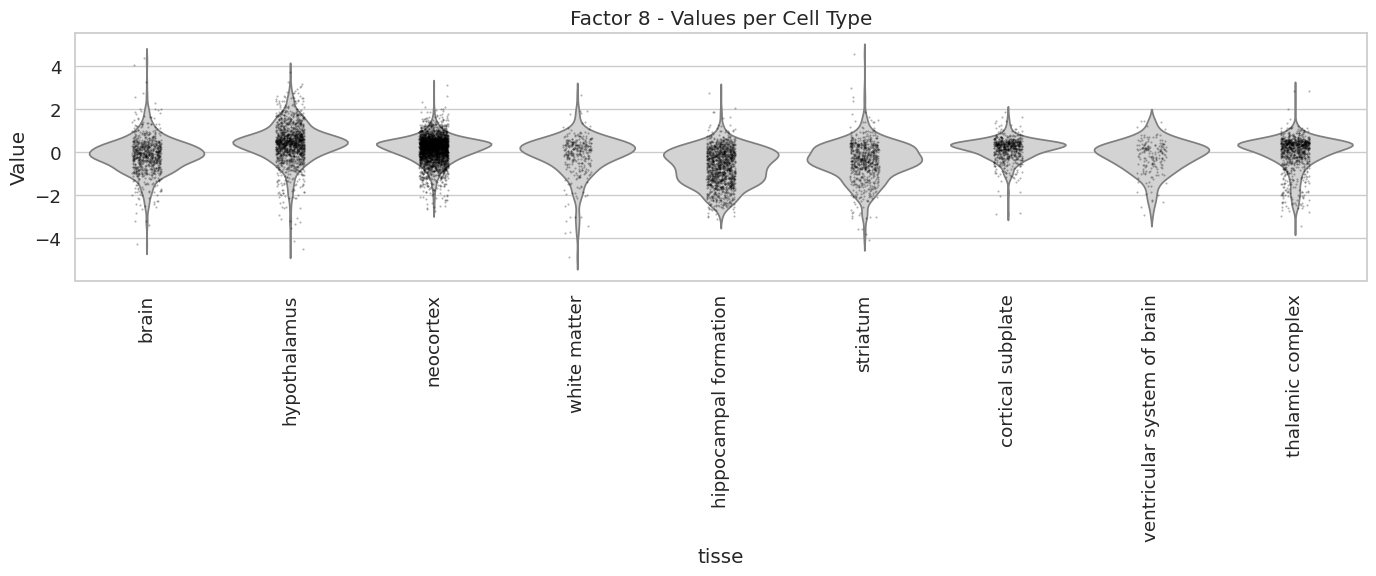

/scratch/jobs/38879061/ipykernel_14419/3427058440.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.


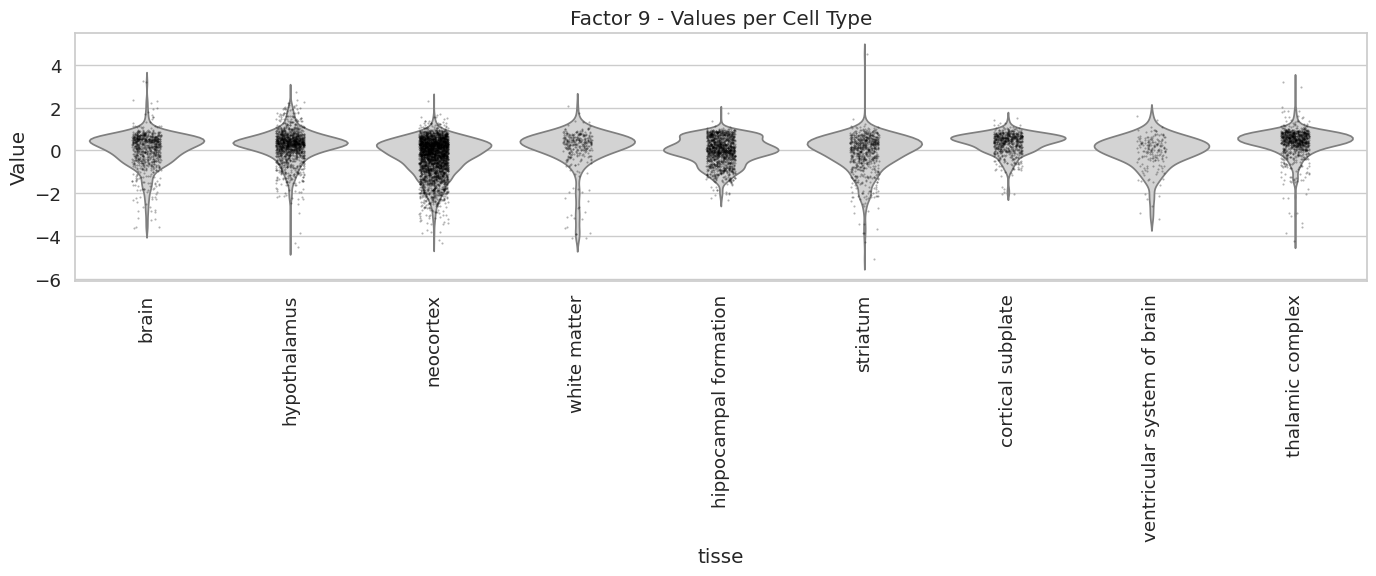

/scratch/jobs/38879061/ipykernel_14419/3427058440.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.


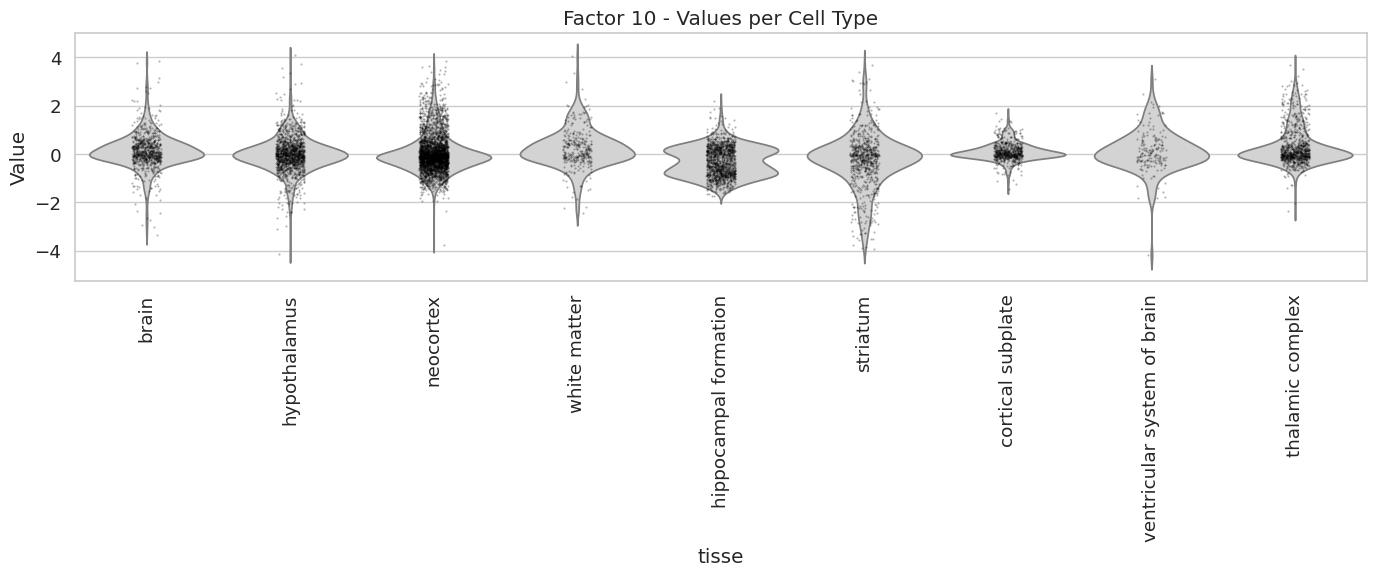

In [230]:
import seaborn as sns
import matplotlib.pyplot as plt

# Loop over each factor
for factor in df_melted['Factor'].unique():
    plt.figure(figsize=(14, 6))
    
    # Violin plot
    sns.violinplot(
        data=df_melted[df_melted['Factor'] == factor],
        x='tisse',
        y='Value',
        inner=None,   # remove quartiles so points are clearer
        scale='width',
        color='lightgray'
    )

    # Add individual data points
    sns.stripplot(
        data=df_melted[df_melted['Factor'] == factor],
        x='tisse',
        y='Value',
        color='black',
        size=1.5,
        jitter=True,    # helps avoid overlapping
        alpha=0.3
    )
    
    plt.xticks(rotation=90)
    plt.title(f'{factor} - Values per Cell Type')
    plt.tight_layout()
    plt.show()


## 3.Weights dist

In [125]:
weights_dict= model.get_weights()

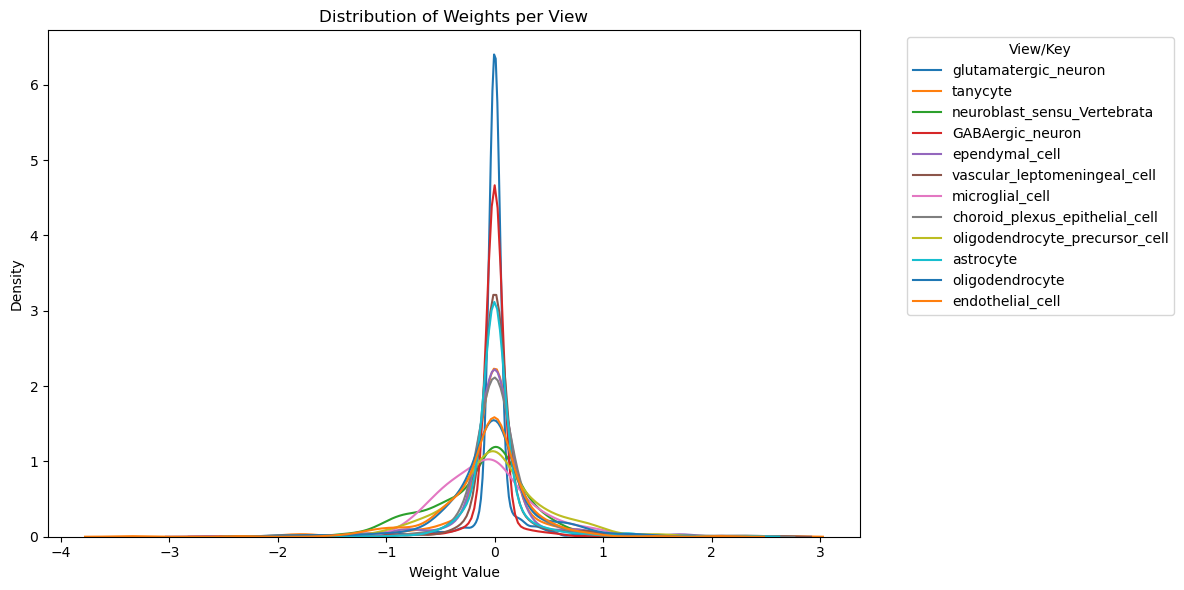

In [126]:
plt.figure(figsize=(12, 6))

# Loop through each view/key
for key, df in weights_dict.items():
    # Flatten all weights from that DataFrame into 1D array
    values = df.values.flatten()
    sns.kdeplot(values, label=key, fill=False)  # distribution curve

plt.title("Distribution of Weights per View")
plt.xlabel("Weight Value")
plt.ylabel("Density")
plt.legend(title="View/Key", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [127]:
#mfl.pl.all_weights(model_gp, views=['fib2'], figsize=(8,8), show_featurenames=True)
#mfl.pl.weights(model, n_features=10, views=["fib2"], factors=1, pointsize=2, figsize=(8,8))
#mfl.pl.top_weights(model, n_features=15, views="fib2", factors=1)

## 4. Heatmap (view x LR)

In [128]:
from string import ascii_uppercase
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [129]:
weights = model.get_weights()

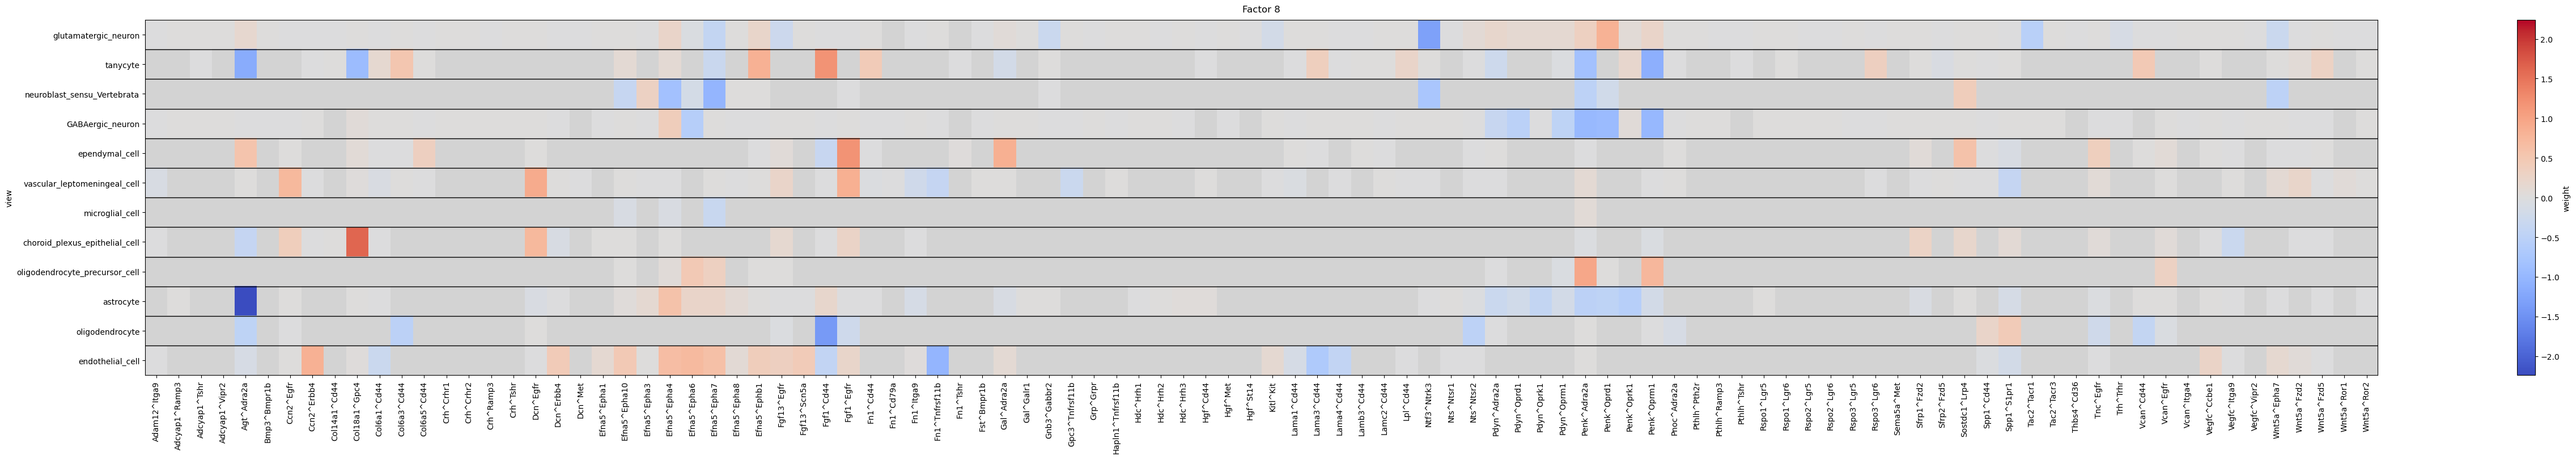

In [130]:
import re
from matplotlib.colors import TwoSlopeNorm

# choose the factor you want:
factor = 8

def resolve_factor_label(df, factor):
    """
    Return the exact row label in df.index for a given factor selector.
    Accepts: 3, "3", "Factor 3", "factor 03", etc.
    """
    idx_map = {str(idx).strip().lower(): idx for idx in df.index}
    key = str(factor).strip().lower()
    # exact match first
    if key in idx_map:
        return idx_map[key]
    # otherwise pull the first integer and try "Factor {n}"
    m = re.search(r'\d+', key)
    if m:
        candidate = f"factor {int(m.group())}"
        if candidate in idx_map:
            return idx_map[candidate]
    raise KeyError(f"Couldn't find factor '{factor}'. Available: {list(df.index)}")

rows, labels = [], []
for view, df in weights.items():
    row_label = resolve_factor_label(df, factor)
    s = df.loc[row_label].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view)

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))

# zero-centered diverging colormap
v = np.nanmax(np.abs(X.values))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad('lightgray')  # NaNs

im = plt.imshow(np.ma.masked_invalid(X.values),
                aspect='auto', interpolation='nearest',
                cmap=cmap, norm=norm)

plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {factor}", pad=10)  # shows "Factor 3" if you passed 3
plt.tight_layout()
plt.show()


# DR using factors values

In [131]:
factors = model.get_factors()
factors = factors["group_1"]

In [132]:
factors

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10
12185986486062748399642964467627918512,-0.267860,0.269622,-0.555714,-0.457027,0.373764,-0.201512,-0.055586,0.401610,-0.227229,0.392137
56898090918706268322480378279645296213,0.116429,0.040470,-0.422958,-0.756447,-0.597422,0.484334,-0.028504,-0.359574,-0.052345,-0.253726
120259415432447893517416781425739794741,1.336947,-2.069736,0.108803,-0.402475,-0.433440,-1.149816,0.476376,-0.188453,-1.165979,-0.752840
62415733978122634249512061004080784872,1.362108,0.455074,0.232663,-0.681101,-0.452172,1.137426,0.461780,0.266150,-0.128262,0.070483
102093083336931440857879796934957752261,1.827404,0.490067,-1.444696,-1.022367,0.158544,1.092117,-2.103214,-1.446146,-0.841974,-0.867165
...,...,...,...,...,...,...,...,...,...,...
300543435981200758297044048836374706712,-0.314667,1.499342,-0.053489,-0.781780,-0.091221,0.066313,-0.326337,0.398581,0.768068,0.372146
312945673217699486459993049617980646276,0.870400,1.105319,0.532509,0.084757,-0.073880,-1.155070,-0.851436,-0.202680,-1.307475,-0.545570
116344495286861894462157516420223807276,-1.800669,0.454564,-1.855682,1.455856,0.445133,-0.269200,-1.130941,-0.227212,-0.556089,-0.307079
17582231177180709444320157527078380982,-0.474713,-0.894972,0.406167,0.303049,0.525431,0.274937,-0.259309,0.200004,0.374973,-0.063481


### Load lrdata

In [133]:
data_path = Path("/g/stegle/aalsayah/repos/data/merfish")
lrdata = sc.read_h5ad(data_path/ "lrdata_animal2_C57BL6J-2.039.h5ad")

In [134]:
lv1 = lrdata.obs["cell_type"]

In [135]:
lv1 = lv1.loc[lv1.index.intersection(factors.index)]
lv1 = lv1.reindex(factors.index)
lv1.shape

(9380,)

In [136]:
lv2 = lrdata.obs["tissue"]
lv2 = lv2.loc[lv2.index.intersection(factors.index)]
lv2 = lv2.reindex(factors.index)
lv2.shape

(9380,)

## UMAP

In [137]:
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
import hdbscan

In [138]:
# --- Standardize ---
scaler = StandardScaler()
X = scaler.fit_transform(factors)

### higher-D

In [139]:
# --- UMAP for clustering (higher-D) ---
umap_clusters = umap.UMAP(
    n_components=10,
    n_neighbors=50,         
    min_dist=0.2,           
    metric="euclidean",      
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [140]:
# --- HDBSCAN: start conservative ---
n = X.shape[0]
mcs = max(30, int(np.sqrt(n)))  
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=mcs,
    min_samples=None,               
    cluster_selection_method="eom",  
    cluster_selection_epsilon=0.05  
).fit(umap_clusters)

labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_rate = (labels == -1).mean()
print(f"clusters={n_clusters}, noise={noise_rate:.2%}")

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


clusters=2, noise=0.00%


#### 2D UMAP

In [141]:
# --- 2D UMAP for visualization only ---
umap2 = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.2,
    metric="euclidean",
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [142]:
df_umap = pd.DataFrame(umap2, columns=['UMAP1','UMAP2'], index=factors.index)
df_umap['Cluster'] = labels
df_umap['Conf'] = clusterer.probabilities_  # how confident each assignment is

#### Plot UMAP

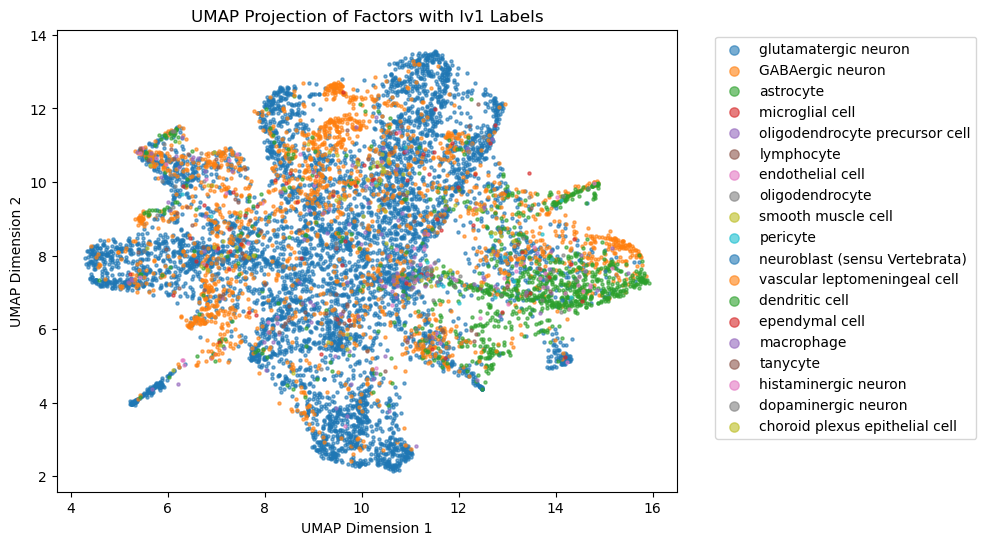

In [143]:
df_umap['Label'] = lv1.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors with lv1 Labels")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

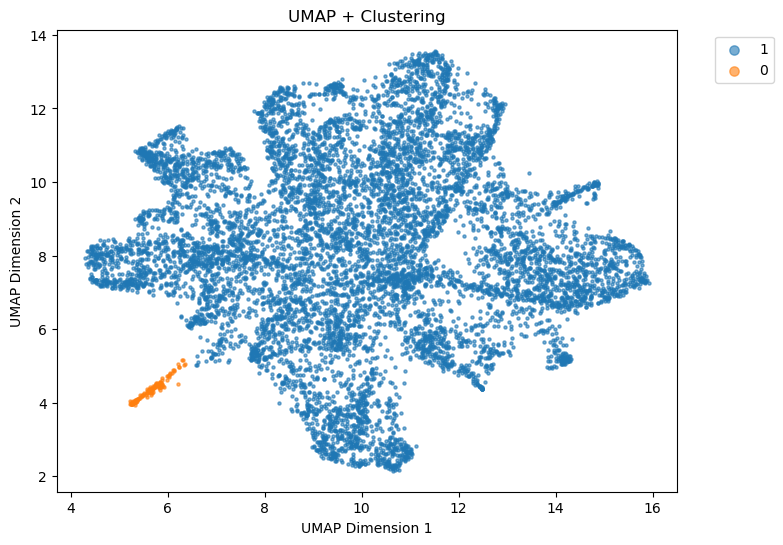

In [144]:
#Plot clusters

plt.figure(figsize=(8,6))
for label in df_umap['Cluster'].unique():
    subset = df_umap[df_umap['Cluster'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP + Clustering")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [145]:
lrdata.obs['F_Cluster'] = df_umap['Cluster'].reindex(lrdata.obs.index)

In [146]:
# Fill NaNs with default cluster value
lrdata.obs['F_Cluster'] = lrdata.obs['F_Cluster'].fillna(-1).astype(str)

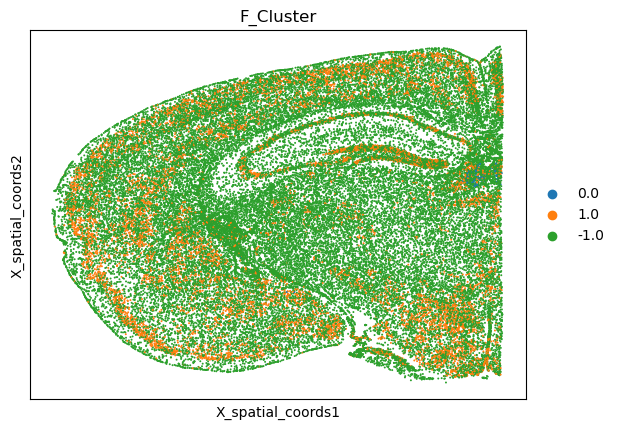

In [147]:
sc.pl.embedding(lrdata, basis="X_spatial_coords", color="F_Cluster", s=8)  # s = point size

# Regression Model

In [148]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [149]:
#get variables 
factors = model.get_factors() 
F = factors["group_1"]

#Get dependent var, change typ to any metadata column you wish to predict if factor values can predict
cell_names = F.index
cell_types = lrdata.obs["tissue"]

# Step 1: Get overlapping indices (cells present in both)
common_cells = F.index.intersection(cell_types.index)

#Sort both
cell_types = cell_types.sort_index()
F=  F.sort_index()


# Step 2: Subset both to those common cells
F = F.loc[common_cells]
cell_types = cell_types.loc[common_cells]

In [150]:
from collections import Counter

# Count cells per class
counts = Counter(cell_types)
valid_classes = [cls for cls, n in counts.items() if n >= 2]

# Keep only those
mask = cell_types.isin(valid_classes)
F = F.loc[mask]
cell_types = cell_types.loc[mask]

In [151]:
# Combine features and labels into one DataFrame temporarily
combined = F.copy()
combined["cell_type"] = cell_types

# Drop any rows with NaNs (in features or cell_type)
combined = combined.dropna()

# Split them back out
F = combined.drop(columns=["cell_type"])
cell_types = combined["cell_type"]

In [152]:
len(F), len(cell_types)

(9380, 9380)

In [153]:
assert all(F.index == cell_types.index)

### Create X and Y objects

In [154]:
F

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10
12185986486062748399642964467627918512,-0.267860,0.269622,-0.555714,-0.457027,0.373764,-0.201512,-0.055586,0.401610,-0.227229,0.392137
56898090918706268322480378279645296213,0.116429,0.040470,-0.422958,-0.756447,-0.597422,0.484334,-0.028504,-0.359574,-0.052345,-0.253726
120259415432447893517416781425739794741,1.336947,-2.069736,0.108803,-0.402475,-0.433440,-1.149816,0.476376,-0.188453,-1.165979,-0.752840
62415733978122634249512061004080784872,1.362108,0.455074,0.232663,-0.681101,-0.452172,1.137426,0.461780,0.266150,-0.128262,0.070483
102093083336931440857879796934957752261,1.827404,0.490067,-1.444696,-1.022367,0.158544,1.092117,-2.103214,-1.446146,-0.841974,-0.867165
...,...,...,...,...,...,...,...,...,...,...
300543435981200758297044048836374706712,-0.314667,1.499342,-0.053489,-0.781780,-0.091221,0.066313,-0.326337,0.398581,0.768068,0.372146
312945673217699486459993049617980646276,0.870400,1.105319,0.532509,0.084757,-0.073880,-1.155070,-0.851436,-0.202680,-1.307475,-0.545570
116344495286861894462157516420223807276,-1.800669,0.454564,-1.855682,1.455856,0.445133,-0.269200,-1.130941,-0.227212,-0.556089,-0.307079
17582231177180709444320157527078380982,-0.474713,-0.894972,0.406167,0.303049,0.525431,0.274937,-0.259309,0.200004,0.374973,-0.063481


In [155]:
cell_types

12185986486062748399642964467627918512            brain
56898090918706268322480378279645296213            brain
120259415432447893517416781425739794741       neocortex
62415733978122634249512061004080784872            brain
102093083336931440857879796934957752261       neocortex
                                               ...     
300543435981200758297044048836374706712    hypothalamus
312945673217699486459993049617980646276    hypothalamus
116344495286861894462157516420223807276    white matter
17582231177180709444320157527078380982            brain
226146086476092669067549420887636486608           brain
Name: cell_type, Length: 9380, dtype: category
Categories (9, object): ['brain', 'hypothalamus', 'neocortex', 'white matter', ..., 'striatum', 'cortical subplate', 'ventricular system of brain', 'thalamic complex']

### Train multinomial logistic regression

In [156]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    F, cell_types, test_size=0.3, random_state=42, stratify=cell_types
)

In [157]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight="balanced"
)

In [158]:
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

### Evaluate the model

In [159]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.4349680170575693

Classification Report:
                              precision    recall  f1-score   support

                      brain       0.42      0.43      0.42       237
          cortical subplate       0.16      0.49      0.24       189
      hippocampal formation       0.72      0.52      0.60       393
               hypothalamus       0.49      0.37      0.42       413
                  neocortex       0.75      0.53      0.62       954
                   striatum       0.31      0.29      0.30       214
           thalamic complex       0.37      0.33      0.35       264
ventricular system of brain       0.08      0.19      0.11        54
               white matter       0.06      0.10      0.08        96

                   accuracy                           0.43      2814
                  macro avg       0.37      0.36      0.35      2814
               weighted avg       0.53      0.43      0.47      2814



### AUC

In [118]:
from sklearn.metrics import roc_auc_score, roc_curve

#### 1. If threr are 2 classes only (REF vs. CRC)

In [105]:
# Get predicted probabilities for the positive class (assume label "232_REF" is positive)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label="222_REF")
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

ValueError: multi_class must be in ('ovo', 'ovr')

#### 2. If classes are more than 2:

In [160]:
# Get class probabilities 
y_proba = clf.predict_proba(X_test)   # shape = (n_samples, 3)

# Compute macro-average AUC (each class equally weighted, good default)
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Multiclass ROC AUC (OvR, macro): {auc_macro:.4f}")

# You could also try weighted averaging (weights by class support):
auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"Multiclass ROC AUC (OvR, weighted): {auc_weighted:.4f}")


Multiclass ROC AUC (OvR, macro): 0.7611
Multiclass ROC AUC (OvR, weighted): 0.8000


# Map clusters to spatial 

In [161]:
df_umap

,UMAP1,UMAP2,Cluster,Conf,Label
12185986486062748399642964467627918512,6.616174,8.134781,1,1.000000,glutamatergic neuron
56898090918706268322480378279645296213,11.292184,10.829125,1,1.000000,glutamatergic neuron
120259415432447893517416781425739794741,14.671474,8.756090,1,1.000000,GABAergic neuron
62415733978122634249512061004080784872,10.417750,11.096751,1,1.000000,glutamatergic neuron
102093083336931440857879796934957752261,10.773221,13.115232,1,1.000000,glutamatergic neuron
...,...,...,...,...,...
300543435981200758297044048836374706712,7.752573,7.383718,1,1.000000,GABAergic neuron
312945673217699486459993049617980646276,8.509758,11.409393,1,1.000000,glutamatergic neuron
116344495286861894462157516420223807276,9.649646,10.906724,1,0.817746,vascular leptomeningeal cell
17582231177180709444320157527078380982,12.489164,6.862427,1,0.835324,astrocyte


In [162]:
clusters = df_umap['Cluster'].reindex(lrdata.obs_names)
print(f"Missing cluster labels: {clusters.isna().sum()}")

Missing cluster labels: 42165


In [163]:
lrdata.obs['Cluster'] = clusters.astype('category')

In [164]:
lrdata

AnnData object with n_obs × n_vars = 51545 × 1360
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'F_Cluster', 'Cluster'
    uns: 'citation', 'moranI', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'F_Cluster_colors'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'
    layers: 'transformed'
    obsp: 'spatial_connectivities'

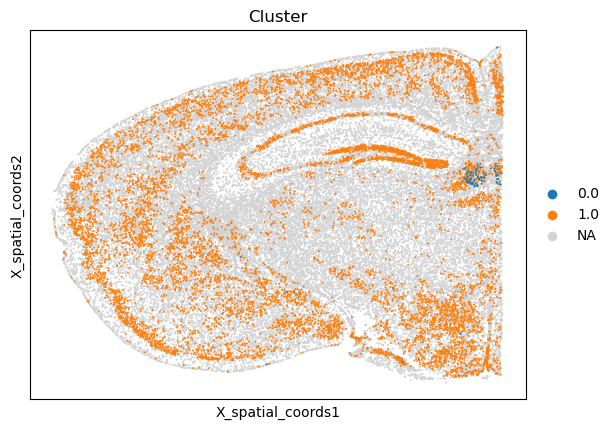

In [165]:
sc.pl.embedding(lrdata, basis="X_spatial_coords", color="Cluster", s=8)  # s = point size